# 1. Import Libraries, Configuration Setup, and Load the Dataset

## 1.1 Install \& Import Libraries

In [1]:
# !pip install peft==0.13.2, transformers==4.41.1

In [2]:
# !pip install wordcloud

In [3]:
# !pip install imblearn

In [4]:
# !pip install lightgbm

In [5]:
# ── Standard library ─────────────────────────────────────
import os
import re
import gc
import json
import time
import random
import warnings
from pathlib import Path
from itertools import product, combinations
from collections import Counter

# ── Stats ────────────────────────────────────────────────
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

# ── Core DS stack ────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── Scikit-learn ─────────────────────────────────────────
from sklearn.model_selection import GroupShuffleSplit
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
    accuracy_score,
)
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils import resample, shuffle
from sklearn.utils.class_weight import compute_class_weight

# ── Other ML ─────────────────────────────────────────────
from lightgbm import LGBMClassifier
import joblib

# ── NLTK ─────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ── PyTorch ──────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from torch.amp import autocast, GradScaler

# ── Transformers ─────────────────────────────────────────
from transformers import (
    AutoTokenizer,
    AlbertForSequenceClassification,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

# ── Notebook setup ───────────────────────────────────────
# %matplotlib inline
warnings.filterwarnings("ignore")
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

True

## 1.2 Seeds \& Device

In [6]:
SEED = 2025

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

USE_FP16 = DEVICE.type == "cuda"
TORCH_COMPILE_OK = hasattr(torch, "compile") and DEVICE.type == "cuda"

Device: cpu


## 1.3 Configuration

In [7]:
DRIVE_PROJECT_PATH = "./03_SameLabel"
RAW_DATA_FILE = "data/mental_health_unified_labels_final.csv"
OUTPUT_DIR = "outputs"

TEXT_COLUMN = "statement"
LABEL_COLUMN = "status"
LABEL_COLUMN_ENCODED = "Status_Encoded" # For our new numeric labels

# Explicit ordinal class order (NOT alphabetical)
CLASS_NAMES = ["Anxiety", "Normal", "Depression", "Suicidal", "Stress", "Bipolar", "Personality disorder"]
NUM_CLASSES = len(CLASS_NAMES)

# Training settings
VOCAB_SIZE = 10000
MAX_TOKEN_LENGTH = 200
BATCH_SIZE = 128
N_ITERATIONS = 10
RANDOM_STATE = 42
SEQ_MAX_GRAD_NORM = 5.0
MAX_GRAD_NORM = 1.0

# ── Model file paths ────────────────────────────────────
OUTPUT_PATH = Path(DRIVE_PROJECT_PATH) / OUTPUT_DIR
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

MODEL_PATHS = {
    "lr":      {"model": OUTPUT_PATH / "best_lr_model.joblib",   "params": OUTPUT_PATH / "best_lr_params.json"},
    "svm":     {"model": OUTPUT_PATH / "best_svm_model.joblib",  "params": OUTPUT_PATH / "best_svm_params.json"},
    "rf":      {"model": OUTPUT_PATH / "best_rf_model.joblib",   "params": OUTPUT_PATH / "best_rf_params.json"},
    "lgbm":    {"model": OUTPUT_PATH / "best_lgbm_model.joblib", "params": OUTPUT_PATH / "best_lgbm_params.json"},
    "gru":     {"model": OUTPUT_PATH / "best_gru_model.pth",     "params": OUTPUT_PATH / "best_gru_params.json"},
    "cnn":     {"model": OUTPUT_PATH / "best_cnn_model.pth",     "params": OUTPUT_PATH / "best_cnn_params.json"},
    "albert":  {"model": OUTPUT_PATH / "best_albert_model.pth",  "params": None},
    "biobert": {"model": OUTPUT_PATH / "best_biobert_model.pth", "params": None},
}

RAW_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, RAW_DATA_FILE)

print("--- Configuration Loaded ---")
print(f"  Project : {DRIVE_PROJECT_PATH}")
print(f"  Classes : {CLASS_NAMES}")
print(f"  FP16    : {USE_FP16}")

--- Configuration Loaded ---
  Project : ./03_SameLabel
  Classes : ['Anxiety', 'Normal', 'Depression', 'Suicidal', 'Stress', 'Bipolar', 'Personality disorder']
  FP16    : False


## 1.4 Mount drive \& Load the data

In [8]:
import os
if os.path.ismount("/content/drive"):
    # Already mounted, skip
    pass
else:
    !fusermount -u /content/drive 2>/dev/null
    !rm -rf /content/drive/*
    from google.colab import drive
    drive.mount("/content/drive/", force_remount=True)

df_raw0 = pd.read_csv(RAW_DATA_PATH, index_col=0)
print(f"Loaded {df_raw0.shape[0]} rows.")

df_raw0.head()

Mounted at /content/drive/
Loaded 53043 rows.


,statement,status,u_label,u_p_normal,u_p_depression,u_p_anxiety,u_p_suicidal,u_p_stress,u_p_bipolar,u_p_personality_disorder,...,u_model_version,u_system_fingerprint,u_annotation_timestamp,u_raw_json,u_n_conditions,u_any_clinical,u_normal_inferred,u_multilabel,u_max_clinical_prob,u_sum_clinical_prob
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,oh my gosh,Anxiety,NORMAL,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",0,False,True,NORMAL,0.0,0.0
1,"trouble sleeping, confused mind, restless hear...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
3,I've shifted my focus to something else but I'...,Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
4,"I'm restless and restless, it's been a month n...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0


In [9]:
def normalize_label(s):
    s = "" if pd.isna(s) else str(s)
    s = s.strip().upper()
    # collapse any whitespace to single underscore
    s = re.sub(r"\s+", "_", s)
    # replace hyphens/slashes with underscore
    s = re.sub(r"[-/]+", "_", s)
    # remove other non-alnum/underscore characters
    s = re.sub(r"[^A-Z0-9_]", "", s)
    # collapse repeated underscores
    s = re.sub(r"_+", "_", s)
    return s

df_raw0["status_upper"] = df_raw0["status"].apply(normalize_label)
df_raw0["u_label_upper"] = df_raw0["u_label"].apply(normalize_label)

df_agree = df_raw0[df_raw0["status_upper"] == df_raw0["u_label_upper"]].copy()
df_disagree = df_raw0[df_raw0["status_upper"] != df_raw0["u_label_upper"]].copy()

print(f"Agree subset: {len(df_agree)} / {len(df_raw0)} ({len(df_agree)/len(df_raw0)*100:.1f}%)")
print(f"Disagree subset: {len(df_disagree)} / {len(df_raw0)} ({len(df_disagree)/len(df_raw0)*100:.1f}%)")

# Optional: quick label breakdown in the agree subset
print("\nAgree subset label distribution:")
print(df_agree["status_upper"].value_counts().to_string())

df_raw = df_agree.copy()
df_raw.head()

Agree subset: 33267 / 53043 (62.7%)
Disagree subset: 19776 / 53043 (37.3%)

Agree subset label distribution:
status_upper
NORMAL                  14310
SUICIDAL                 7466
DEPRESSION               6461
ANXIETY                  3304
BIPOLAR                  1058
STRESS                    595
PERSONALITY_DISORDER       73


,statement,status,u_label,u_p_normal,u_p_depression,u_p_anxiety,u_p_suicidal,u_p_stress,u_p_bipolar,u_p_personality_disorder,...,u_annotation_timestamp,u_raw_json,u_n_conditions,u_any_clinical,u_normal_inferred,u_multilabel,u_max_clinical_prob,u_sum_clinical_prob,status_upper,u_label_upper
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
1,"trouble sleeping, confused mind, restless hear...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0,ANXIETY,ANXIETY
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0,ANXIETY,ANXIETY
3,I've shifted my focus to something else but I'...,Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0,ANXIETY,ANXIETY
4,"I'm restless and restless, it's been a month n...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0,ANXIETY,ANXIETY
5,"every break, you must be nervous, like somethi...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0,ANXIETY,ANXIETY


# 2. Data Exploration \& Master Data Preparation

## 2.1 Data Preparation

In [10]:
# Shuffle
df_raw = shuffle(df_raw, random_state=SEED).reset_index(drop=True)
df_raw

,statement,status,u_label,u_p_normal,u_p_depression,u_p_anxiety,u_p_suicidal,u_p_stress,u_p_bipolar,u_p_personality_disorder,...,u_annotation_timestamp,u_raw_json,u_n_conditions,u_any_clinical,u_normal_inferred,u_multilabel,u_max_clinical_prob,u_sum_clinical_prob,status_upper,u_label_upper
0,"ndes. Marina, why does it open the shelves in ...",Normal,NORMAL,0.9,0.0,0.0,0.0,0.0,0.0,0.1,...,2026-02-27T18:28:24.955910,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",0,False,True,NORMAL,0.1,0.1,NORMAL,NORMAL
1,there is already an open go jjk vol. 16 hahaha...,Normal,NORMAL,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2026-02-27T18:28:24.995525,"[\n {\n ""index"": 0,\n ""label""...",0,False,True,NORMAL,0.0,0.0,NORMAL,NORMAL
2,for the last five to seven year at least i ve ...,Depression,DEPRESSION,0.0,0.7,0.0,0.0,0.3,0.0,0.0,...,2026-02-27T22:50:42.897357,"[\n {\n ""index"": 0,\n ""label""...",2,True,False,DEPRESSION+STRESS,0.7,1.0,DEPRESSION,DEPRESSION
3,@coy0te Good morning! Feeling happier today?,Normal,NORMAL,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2026-02-27T22:23:15.862265,"[\n {\n ""index"": 0,\n ""label""...",0,False,True,NORMAL,0.0,0.0,NORMAL,NORMAL
4,tutsy e say e wan heal from the depression tor...,Depression,DEPRESSION,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,2026-02-27T22:57:13.595801,"[\n {\n ""index"": 0,\n ""label"": ""DEPRESS...",1,True,False,DEPRESSION,1.0,1.0,DEPRESSION,DEPRESSION
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33262,24/7 i cringe at my past thoughts omg its so p...,Suicidal,SUICIDAL,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2026-02-27T21:05:39.264255,"[\n {\n ""index"": 0,\n ""label""...",2,True,False,DEPRESSION+SUICIDAL,1.0,1.0,SUICIDAL,SUICIDAL
33263,"I do not want to work on myself, idc about mys...",Suicidal,SUICIDAL,0.0,0.0,0.0,0.9,0.1,0.0,0.0,...,2026-02-27T20:07:03.475060,"[\n {\n ""index"": 0,\n ""label"": ""DEPRESS...",2,True,False,DEPRESSION+SUICIDAL,0.9,1.0,SUICIDAL,SUICIDAL
33264,it is completely out of the blue now...usually...,Depression,DEPRESSION,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,2026-02-27T21:09:36.708514,"[\n {\n ""index"": 0,\n ""label"": ""SUICIDA...",1,True,False,DEPRESSION,1.0,1.0,DEPRESSION,DEPRESSION
33265,Separation anxiety w/ my bsf I've recently sta...,Anxiety,ANXIETY,0.0,0.0,0.9,0.0,0.1,0.0,0.0,...,2026-02-28T00:04:39.830593,"[\n {\n ""index"": 0,\n ""label"": ""ANXIETY...",1,True,False,ANXIETY,0.9,1.0,ANXIETY,ANXIETY


## 2.2 Master Data Preparation

In [11]:
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", " urltoken ", text)
    text = re.sub(r"@\w+", " usertoken ", text)
    text = re.sub(r"#(\w+)", r" hashtag_\1 ", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


print("Cleaning text...")
df_clean = df_raw.copy()
df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].apply(clean_text)

Cleaning text...


In [12]:
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(CLASS_NAMES)  # force ordinal order
df_clean[LABEL_COLUMN_ENCODED] = label_encoder.transform(df_clean[LABEL_COLUMN])

print(f"Label mapping: {dict(zip(CLASS_NAMES, range(NUM_CLASSES)))}")
print(f"df_clean: {df_clean.shape[0]} rows")


Label mapping: {'Anxiety': 0, 'Normal': 1, 'Depression': 2, 'Suicidal': 3, 'Stress': 4, 'Bipolar': 5, 'Personality disorder': 6}
df_clean: 33267 rows


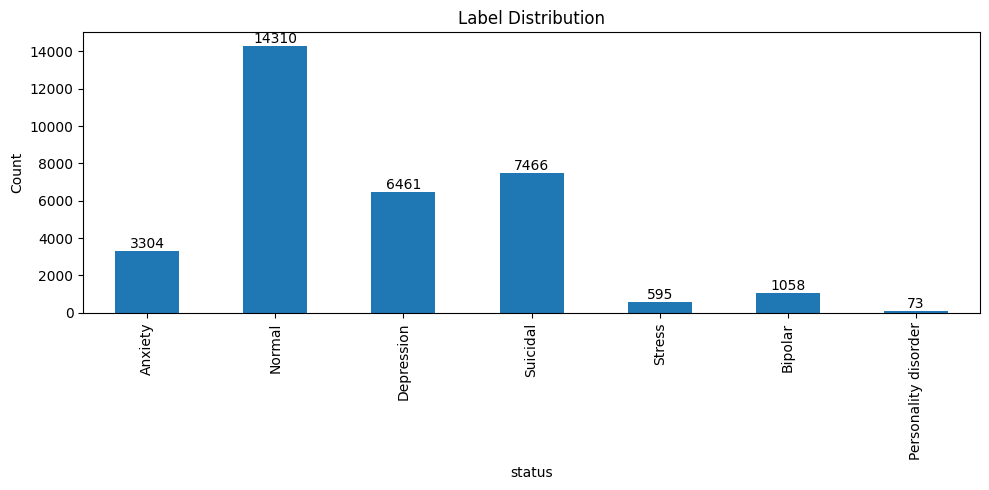

In [13]:
plt.figure(figsize=(10, 5))
counts = df_clean[LABEL_COLUMN].value_counts().reindex(CLASS_NAMES)
ax = counts.plot(kind="bar")
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.title("Label Distribution")
plt.xlabel(LABEL_COLUMN)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 2.3 Master Data Split

In [14]:
groups = df_clean[TEXT_COLUMN]
y = df_clean[LABEL_COLUMN_ENCODED]

# 80/20 → trainval / test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss_test.split(df_clean, y, groups=groups))

split = np.full(len(df_clean), "train", dtype=object)
split[test_idx] = "test"

# 75/25 of trainval → train / val (≈60/20/20)
df_trainval = df_clean.iloc[trainval_idx].copy().reset_index(drop=True)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx2, val_idx = next(
    gss_val.split(df_trainval, df_trainval[LABEL_COLUMN_ENCODED], groups=df_trainval[TEXT_COLUMN])
)
split[trainval_idx[val_idx]] = "val"
df_clean["split"] = split

print("Split counts:")
print(df_clean["split"].value_counts())

# Leakage check
n_leaky = (df_clean.groupby(TEXT_COLUMN)["split"].nunique() > 1).sum()
assert n_leaky == 0, f"{n_leaky} text groups leak across splits!"
print(f"Leakage check passed.")

print("Split proportions:")
print(df_clean["split"].value_counts(normalize=True))

# Save master split
split_path = OUTPUT_PATH / "MentalHealth_master_split.csv"
df_clean.to_csv(split_path, index=False)
print(f"Saved → {split_path}")

Split counts:
split
train    19924
val       6675
test      6668
Name: count, dtype: int64
Leakage check passed.
Split proportions:
split
train    0.598912
val      0.200649
test     0.200439
Name: proportion, dtype: float64
Saved → ./03_SameLabel/outputs/MentalHealth_master_split.csv


## 2.4 Shared helper functions

### 2.4.1 Bootstrap CI

In [ ]:
def bootstrap_f1_ci(y_true, y_pred, n_iterations=1000, average="weighted"):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(f1_score(y_true[idx], y_pred[idx], average=average))
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)


def bootstrap_auc_ci(y_true, y_scores, n_iterations=1000, average="macro"):
    y_true, y_scores = np.asarray(y_true), np.asarray(y_scores)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(
                roc_auc_score(y_true[idx], y_scores[idx], average=average, multi_class="ovr")
            )
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

### 2.4.2 Plotting

In [ ]:
def plot_confusion_matrix(y_true, y_pred, labels, title="Model", save_dir=None):
    """Works for both string labels (ML) and int labels (DL)."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {title}")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_confusion_matrix.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()


def plot_multiclass_roc(y_true, y_score, classes_list, title="Model", save_dir=None):
    """Works for both string and int class lists."""
    y_true_bin = label_binarize(y_true, classes=classes_list)
    n_classes = len(classes_list)
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = sns.color_palette("mako", n_classes)
    plt.figure(figsize=(10, 8))
    for i, (cls, color) in enumerate(zip(classes_list, colors)):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f"{cls} (AUC={roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title} — Multi-class ROC")
    plt.legend(loc="lower right")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_roc_curve.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()

### 2.4.3 Machine Learning Evaluation Wrapper

In [ ]:
def evaluate_ml(model, X_test, y_test, model_name="Model"):
    """Full evaluation for a fitted sklearn classifier."""
    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*50}")

    y_pred = model.predict(X_test)
    classes = model.classes_

    print(classification_report(y_test, y_pred, digits=4, labels=classes))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(y_test, y_pred)
    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

    plot_confusion_matrix(y_test, y_pred, labels=classes,
                         title=model_name, save_dir=str(OUTPUT_PATH))

    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        print("No probability scores available.")
        return

    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(y_test, y_scores)
    print(f"Macro AUC: {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_multiclass_roc(y_test, y_scores, classes,
                       title=model_name, save_dir=str(OUTPUT_PATH))

### 2.4.4 PyTorch Evaluation Wrapper

In [ ]:
@torch.no_grad()
def evaluate_pytorch(model, test_loader, label_encoder, model_name="Model",
                     use_attention_mask=True):
    """Full evaluation for a PyTorch classifier."""
    model.eval().to(DEVICE)
    all_preds, all_probs, all_labels = [], [], []

    for batch in tqdm(test_loader, desc=f"Eval {model_name}"):
        ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        if use_attention_mask:
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids, attention_mask=mask)
        else:
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids)

        logits = outputs.logits if hasattr(outputs, "logits") else outputs
        probs = torch.softmax(logits.float(), dim=1)
        preds = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    classes_str = label_encoder.classes_
    classes_int = np.arange(NUM_CLASSES)

    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*50}")

    print(classification_report(all_labels, all_preds,
                                target_names=classes_str, digits=4))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(all_labels, all_preds)
    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

    plot_confusion_matrix(all_labels, all_preds, labels=classes_int,
                         title=model_name, save_dir=str(OUTPUT_PATH))

    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(all_labels, all_probs)
    print(f"Macro AUC: {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_multiclass_roc(all_labels, all_probs, classes_int,
                       title=model_name, save_dir=str(OUTPUT_PATH))

    return all_preds, all_probs, all_labels

### 2.4.5 Machine Learning Feature Importance (shared)

In [ ]:

def plot_feature_importance(importances, feature_names, model_name="Model", top_n=20):
    """Generic feature importance plot for any ML model."""
    df_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    df_imp["Scaled"] = (df_imp["Importance"] / df_imp["Importance"].max()) * 100
    top = df_imp.sort_values("Importance", ascending=False).head(top_n)

    plt.figure(figsize=(8, 6))
    sns.set_style("whitegrid")
    sns.barplot(x="Scaled", y="Feature", data=top[::-1], palette="mako")
    plt.title(f"Top {top_n} Feature Importance ({model_name})", fontsize=14, fontweight="bold")
    plt.xlabel("Relative Importance (%)")
    plt.ylabel("Feature")
    plt.tight_layout()

    path = OUTPUT_PATH / f"{model_name.lower().replace(' ', '_')}_feature_importance.png"
    plt.savefig(path, dpi=300)
    print(f"Saved → {path}")
    plt.show()

    return top

# 3. Classical ML Modeling

## 3.0 Pre-processing for classical ML Models


In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def ml_preprocess(text: str) -> str:
    if not isinstance(text, str):
        return ""
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return " ".join(tokens)


df_ml = df_clean.copy()
df_ml["text_ml"] = df_ml[TEXT_COLUMN].apply(ml_preprocess)

df_train_ml = df_ml[df_ml["split"] == "train"].copy()
df_val_ml   = df_ml[df_ml["split"] == "val"].copy()
df_test_ml  = df_ml[df_ml["split"] == "test"].copy()

X_train_ml = df_train_ml["text_ml"].tolist()
X_val_ml   = df_val_ml["text_ml"].tolist()
X_test_ml  = df_test_ml["text_ml"].tolist()

y_train_ml = df_train_ml[LABEL_COLUMN].astype(str).values
y_val_ml   = df_val_ml[LABEL_COLUMN].astype(str).values
y_test_ml  = df_test_ml[LABEL_COLUMN].astype(str).values

# TF-IDF (no stop_words param — already removed in ml_preprocess)
tfidf = TfidfVectorizer(max_features=VOCAB_SIZE)
X_train_tfidf = tfidf.fit_transform(X_train_ml)
X_val_tfidf   = tfidf.transform(X_val_ml)
X_test_tfidf  = tfidf.transform(X_test_ml)

print(f"TF-IDF: train={X_train_tfidf.shape}, val={X_val_tfidf.shape}, test={X_test_tfidf.shape}")
feature_names_tfidf = tfidf.get_feature_names_out()

print(f"ML splits: train={len(df_train_ml)}, val={len(df_val_ml)}, test={len(df_test_ml)}")

TF-IDF: train=(19924, 10000), val=(6675, 10000), test=(6668, 10000)
ML splits: train=19924, val=6675, test=6668


## 3.1 Logistic Regression

### Step 1: Hyperparameter Tuning

In [ ]:
RETRAIN = True
if RETRAIN:
    # 7.1 Hyperparameter Tuning (grid search)
    set_seed()
    print("Tuning Logistic Regression...")
    start = time.time()

    lr_grid = {
        "C": [0.1, 1, 10],
        "solver": ["lbfgs", "saga"],
        "class_weight": ["balanced", None],
    }

    best_f1_lr, best_model_lr, best_params_lr = 0, None, None

    for C, solver, cw in product(lr_grid["C"], lr_grid["solver"], lr_grid["class_weight"]):
        try:
            model = LogisticRegression(
                C=C, solver=solver, penalty="l2", multi_class="multinomial",
                class_weight=cw, max_iter=1000, random_state=RANDOM_STATE,
                n_jobs=-1 if solver == "saga" else None,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_lr:
                best_f1_lr = f1
                best_model_lr = model
                best_params_lr = {"C": C, "solver": solver, "class_weight": cw}
                print(f"  LR F1={f1:.4f} | {best_params_lr}")
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"LR tuning: {time.time()-start:.1f}s | Best F1={best_f1_lr:.4f}")

    joblib.dump(best_model_lr, MODEL_PATHS["lr"]["model"])
    with open(MODEL_PATHS["lr"]["params"], "w") as f:
        json.dump(best_params_lr, f, indent=2)
else:
    print("Loading LR from disk...")
    best_model_lr = joblib.load(MODEL_PATHS["lr"]["model"])
    print(f"Loaded LR from {MODEL_PATHS['lr']['model']}")

Tuning Logistic Regression...
  LR F1=0.8635 | {'C': 0.1, 'solver': 'lbfgs', 'class_weight': 'balanced'}
  LR F1=0.8974 | {'C': 1, 'solver': 'lbfgs', 'class_weight': 'balanced'}
  LR F1=0.9039 | {'C': 10, 'solver': 'lbfgs', 'class_weight': 'balanced'}
LR tuning: 158.2s | Best F1=0.9039


### Step 2: Model Evaluation


Evaluation: Logistic_Regression
                      precision    recall  f1-score   support

             Anxiety     0.9363    0.9348    0.9356       629
             Bipolar     0.9534    0.9000    0.9259       250
          Depression     0.8321    0.8527    0.8423      1290
              Normal     0.9538    0.9690    0.9613      2835
Personality disorder     1.0000    0.5333    0.6957        15
              Stress     0.8244    0.8244    0.8244       131
            Suicidal     0.8729    0.8412    0.8568      1518

            accuracy                         0.9078      6668
           macro avg     0.9104    0.8365    0.8631      6668
        weighted avg     0.9077    0.9078    0.9074      6668

Weighted F1: 0.9074  95% CI [0.9005, 0.9140]
Saved → ./03_SameLabel/outputs/Logistic_Regression_confusion_matrix.png


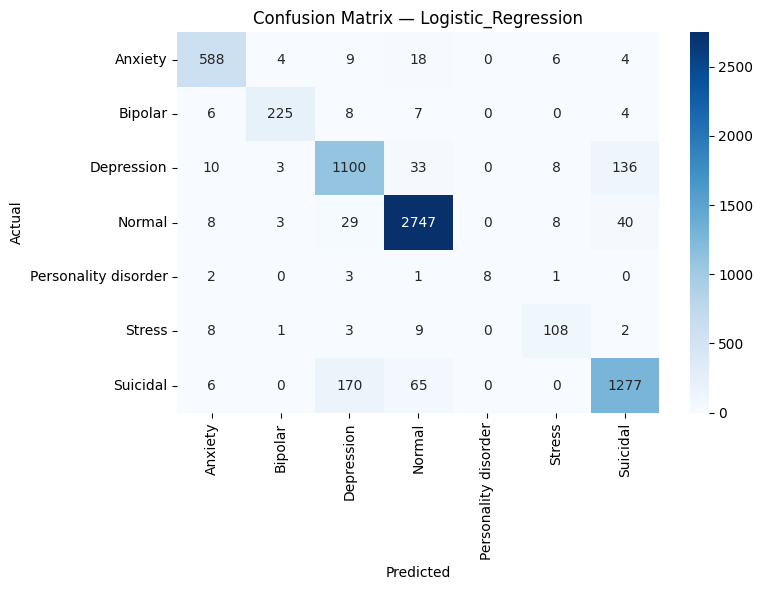

Macro AUC: 0.9894  95% CI [0.9860, 0.9918]
Saved → ./03_SameLabel/outputs/Logistic_Regression_roc_curve.png


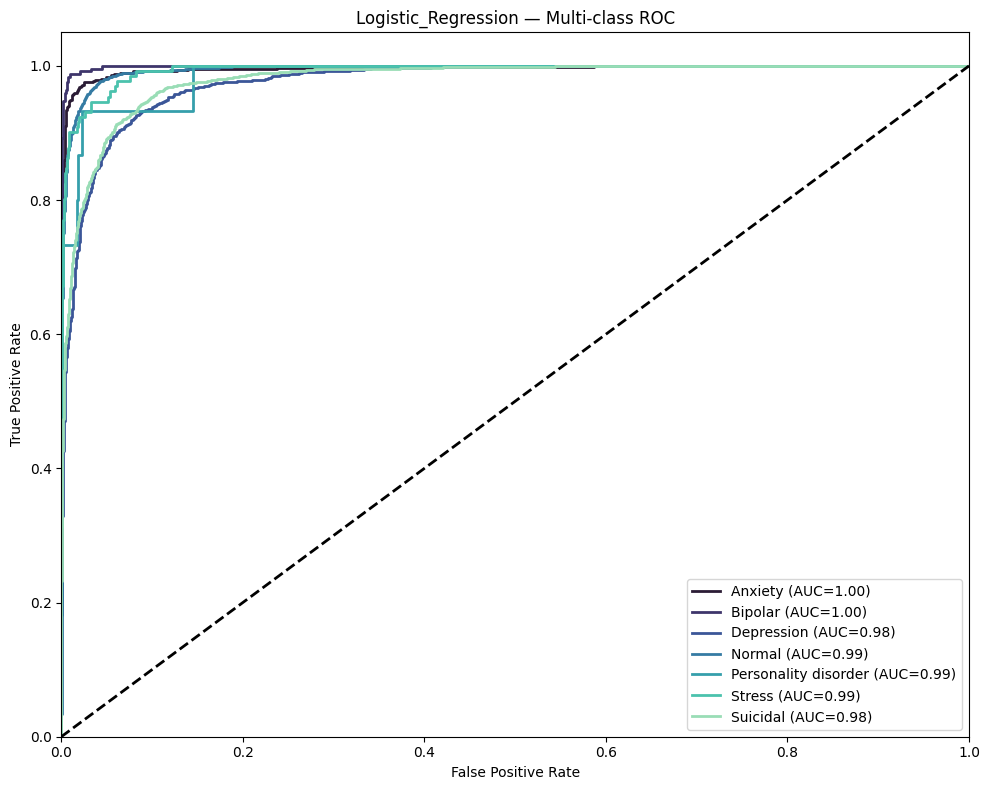

In [ ]:
evaluate_ml(best_model_lr, X_test_tfidf, y_test_ml, "Logistic_Regression")

### Step 3: Model Interpretation

Saved → ./03_SameLabel/outputs/logistic_regression_feature_importance.png


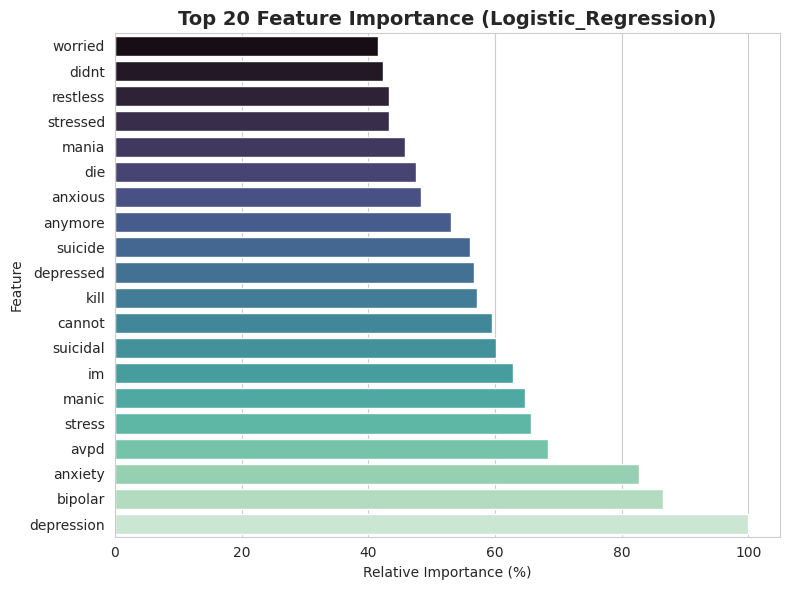

In [ ]:
if hasattr(best_model_lr, "coef_"):
    importances_lr = np.abs(best_model_lr.coef_).mean(axis=0) if best_model_lr.coef_.shape[0] > 1 else np.abs(best_model_lr.coef_[0])
    plot_feature_importance(importances_lr, feature_names_tfidf, "Logistic_Regression")

## 3.2 SVM

### Step 1: Hyperparameter Tuning

In [ ]:
### Step 1: Hyperparameter Tuning

RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning SVM...")
    start = time.time()

    svm_grid = {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "class_weight": ["balanced", None],
        "gamma": ["scale"],
    }

    best_f1_svm, best_params_svm, best_model_svm = 0, None, None

    for C, kernel, class_weight, gamma in product(
        svm_grid["C"], svm_grid["kernel"],
        svm_grid["class_weight"], svm_grid["gamma"]
    ):
        try:
            model = SVC(
                C=C, kernel=kernel, class_weight=class_weight,
                gamma=gamma, random_state=RANDOM_STATE, probability=False,
            )
            model.fit(X_train_tfidf, y_train_ml)
            y_val_pred = model.predict(X_val_tfidf)
            f1 = f1_score(y_val_ml, y_val_pred, average="weighted")

            if f1 > best_f1_svm:
                best_f1_svm = f1
                best_params_svm = {"C": C, "kernel": kernel,
                                   "class_weight": class_weight, "gamma": gamma}
                best_model_svm = model
                print(f"  New best F1: {f1:.4f} | {best_params_svm}")

        except Exception as e:
            print(f"  Skipping: {e}")

    # Retrain best config with probability=True for predict_proba
    print("\nRetraining best SVM with probability=True...")
    best_model_svm = SVC(
        **best_params_svm,
        random_state=RANDOM_STATE, probability=True,
    )
    best_model_svm.fit(X_train_tfidf, y_train_ml)

    elapsed = time.time() - start
    print(f"\nBest SVM: F1={best_f1_svm:.4f} in {elapsed:.1f}s")
    print(f"Params: {best_params_svm}")

    joblib.dump(best_model_svm, MODEL_PATHS["svm"]["model"])
    with open(MODEL_PATHS["svm"]["params"], "w") as f:
        json.dump(best_params_svm, f, indent=2)
    print(f"Saved best SVM model to: {MODEL_PATHS['svm']['model']}")
else:
    best_model_svm = joblib.load(MODEL_PATHS["svm"]["model"])
    with open(MODEL_PATHS["svm"]["params"]) as f:
        best_params_svm = json.load(f)
    print(f"Loaded saved SVM model. Params: {best_params_svm}")


Tuning SVM...
  New best F1: 0.8774 | {'C': 0.1, 'kernel': 'linear', 'class_weight': 'balanced', 'gamma': 'scale'}
  New best F1: 0.9029 | {'C': 1, 'kernel': 'linear', 'class_weight': 'balanced', 'gamma': 'scale'}

Retraining best SVM with probability=True...

Best SVM: F1=0.9029 in 1354.7s
Params: {'C': 1, 'kernel': 'linear', 'class_weight': 'balanced', 'gamma': 'scale'}
Saved best SVM model to: ./03_SameLabel/outputs/best_svm_model.joblib


### Step 2: Model Evaluation


Evaluation: SVM
                      precision    recall  f1-score   support

             Anxiety     0.9110    0.9444    0.9274       629
             Bipolar     0.9685    0.8600    0.9110       250
          Depression     0.8283    0.8636    0.8455      1290
              Normal     0.9545    0.9683    0.9613      2835
Personality disorder     1.0000    0.3333    0.5000        15
              Stress     0.8174    0.7176    0.7642       131
            Suicidal     0.8851    0.8472    0.8657      1518

            accuracy                         0.9078      6668
           macro avg     0.9092    0.7906    0.8250      6668
        weighted avg     0.9081    0.9078    0.9072      6668

Weighted F1: 0.9070  95% CI [0.8996, 0.9142]
Saved → ./03_SameLabel/outputs/SVM_confusion_matrix.png


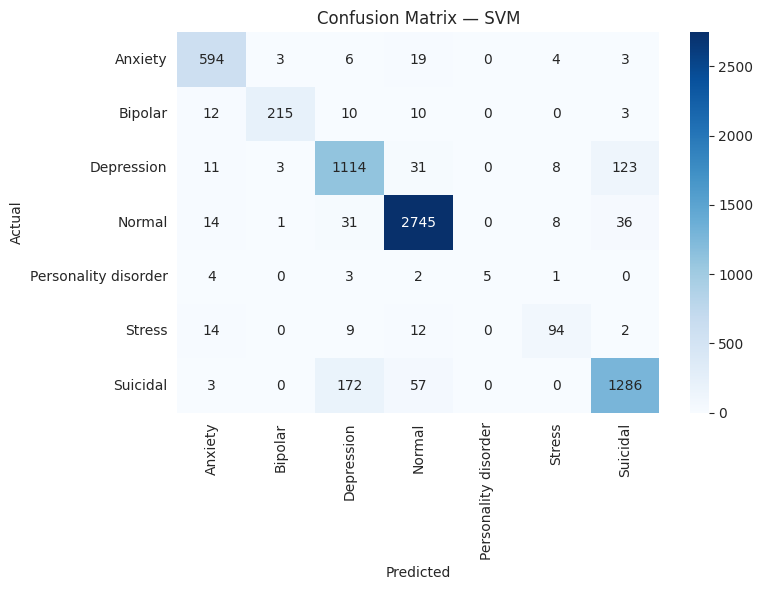

Macro AUC: 0.9883  95% CI [0.9813, 0.9924]
Saved → ./03_SameLabel/outputs/SVM_roc_curve.png


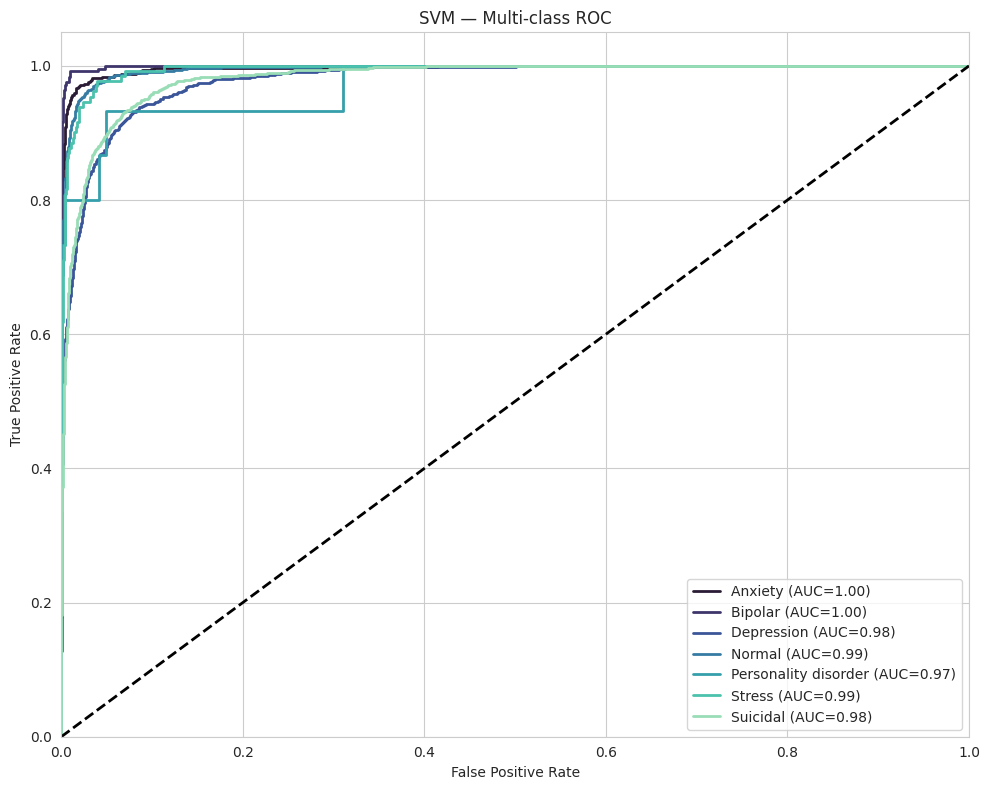

In [ ]:
evaluate_ml(best_model_svm, X_test_tfidf, y_test_ml, "SVM")

### Step 3: Model Interpretation

In [ ]:
# if best_model_svm.kernel == "linear" and hasattr(best_model_svm, "coef_"):
#     # Linear kernel: use coefficient weights directly (fast)
#     importances_svm = np.abs(best_model_svm.coef_).mean(axis=0)
#     if hasattr(importances_svm, "A1"):  # sparse matrix → flat array
#         importances_svm = importances_svm.A1
#     plot_feature_importance(importances_svm, feature_names_tfidf, "SVM")
# else:
#     # Non-linear kernel: permutation importance (slower)
#     print(f"Kernel='{best_model_svm.kernel}' — using permutation importance...")

#     max_samples = 1000
#     n_val = X_val_tfidf.shape[0]

#     if n_val > max_samples:
#         rng = np.random.RandomState(RANDOM_STATE)
#         idx = rng.choice(n_val, size=max_samples, replace=False)
#         X_perm = X_val_tfidf[idx]
#         y_perm = y_val_ml.iloc[idx] if hasattr(y_val_ml, "iloc") else y_val_ml[idx]
#     else:
#         X_perm = X_val_tfidf
#         y_perm = y_val_ml

#     print(f"Permutation importance on {X_perm.shape[0]} samples...")
#     start = time.time()

#     result = permutation_importance(
#         best_model_svm, X_perm, y_perm,
#         n_repeats=5, random_state=RANDOM_STATE,
#         n_jobs=-1, scoring="f1_weighted",
#     )

#     print(f"Done in {time.time() - start:.1f}s")

#     importances_svm = result.importances_mean.clip(min=0)
#     plot_feature_importance(importances_svm, feature_names_tfidf, "SVM")

## 3.3 Random Forest

### Step 1: Hyperparameter Tuning

In [ ]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning Random Forest...")
    start = time.time()

    rf_grid = {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "class_weight": ["balanced", None],
    }

    best_f1_rf, best_model_rf, best_params_rf = 0, None, None

    for n_est, md, mss, msl, cw in tqdm(
        list(product(rf_grid["n_estimators"], rf_grid["max_depth"],
                     rf_grid["min_samples_split"], rf_grid["min_samples_leaf"],
                     rf_grid["class_weight"])),
        desc="RF grid"
    ):
        try:
            model = RandomForestClassifier(
                n_estimators=n_est, max_depth=md, min_samples_split=mss,
                min_samples_leaf=msl, class_weight=cw,
                random_state=RANDOM_STATE, n_jobs=-1,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_rf:
                best_f1_rf = f1
                best_model_rf = model
                best_params_rf = {"n_estimators": n_est, "max_depth": md,
                                  "min_samples_split": mss, "min_samples_leaf": msl,
                                  "class_weight": cw}
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"RF tuning: {time.time()-start:.1f}s | Best F1={best_f1_rf:.4f}")
    print(f"Best params: {best_params_rf}")

    joblib.dump(best_model_rf, MODEL_PATHS["rf"]["model"])
    with open(MODEL_PATHS["rf"]["params"], "w") as f:
        json.dump(best_params_rf, f, indent=2)
else:
    print("Loading RF from disk...")
    best_model_rf = joblib.load(MODEL_PATHS["rf"]["model"])
    print(f"Loaded RF from {MODEL_PATHS['rf']['model']}")


Tuning Random Forest...


RF grid: 100%|██████████| 162/162 [04:31<00:00,  1.67s/it]


RF tuning: 271.2s | Best F1=0.8732
Best params: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 2, 'class_weight': 'balanced'}


### Step 2: Model Evaluation


Evaluation: RandomForest
                      precision    recall  f1-score   support

             Anxiety     0.7944    0.9459    0.8636       629
             Bipolar     0.9539    0.8280    0.8865       250
          Depression     0.8010    0.7798    0.7903      1290
              Normal     0.9514    0.9531    0.9522      2835
Personality disorder     0.0000    0.0000    0.0000        15
              Stress     0.9286    0.4962    0.6468       131
            Suicidal     0.8177    0.8274    0.8225      1518

            accuracy                         0.8745      6668
           macro avg     0.7496    0.6901    0.7088      6668
        weighted avg     0.8746    0.8745    0.8724      6668

Weighted F1: 0.8723  95% CI [0.8646, 0.8804]
Saved → ./03_SameLabel/outputs/RandomForest_confusion_matrix.png


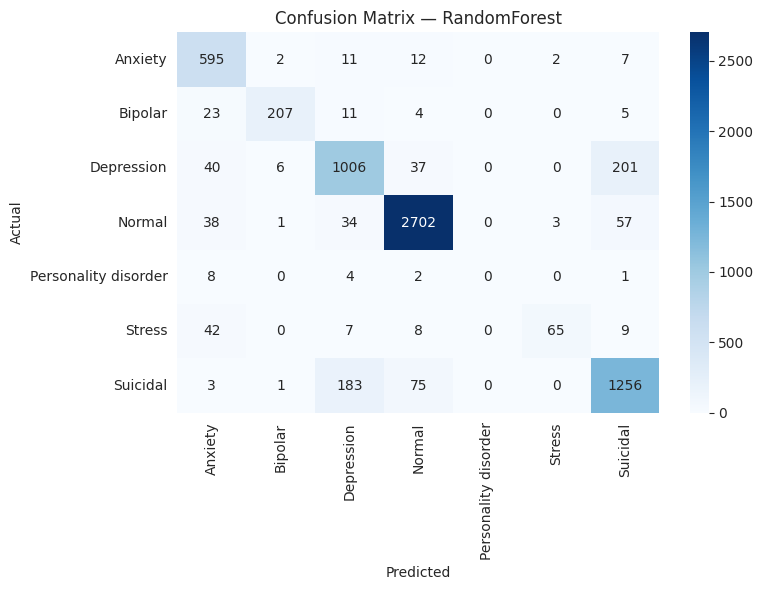

Macro AUC: 0.9810  95% CI [0.9771, 0.9841]
Saved → ./03_SameLabel/outputs/RandomForest_roc_curve.png


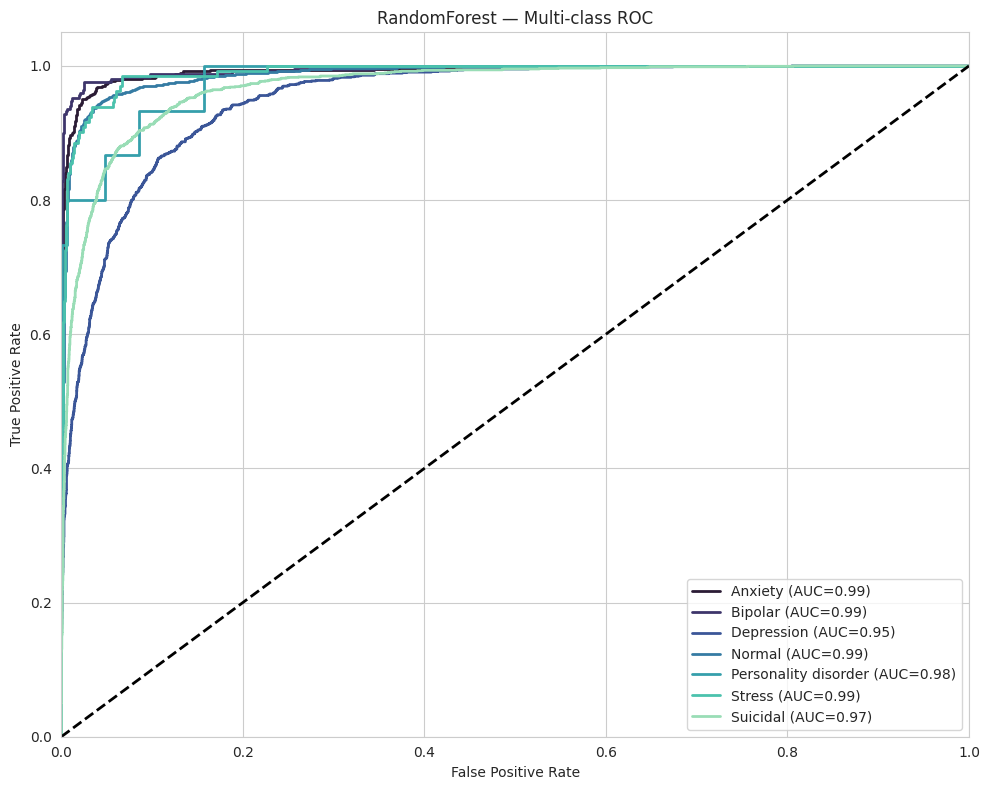

In [ ]:
evaluate_ml(best_model_rf, X_test_tfidf, y_test_ml, "RandomForest")

### Step 3: Model Interpretation

Saved → ./03_SameLabel/outputs/randomforest_feature_importance.png


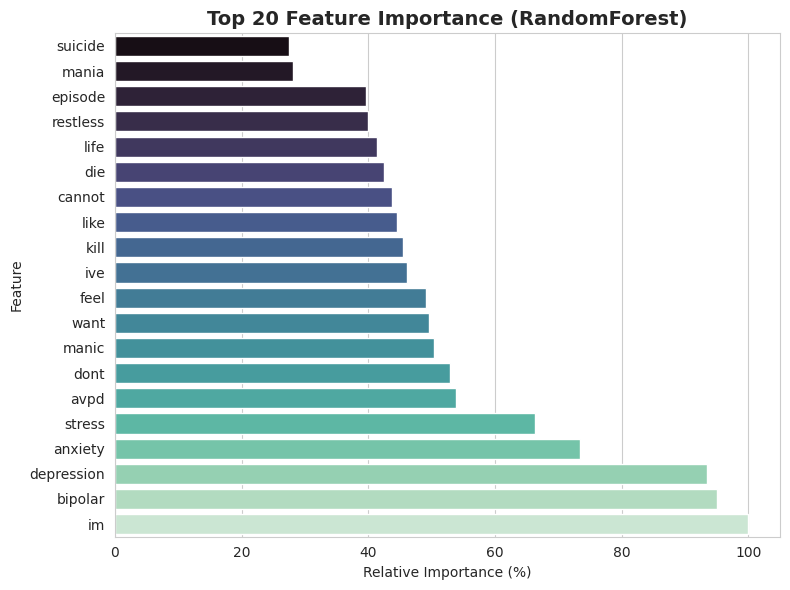

,Feature,Importance,Scaled
4520,im,0.022714,100.000000
1138,bipolar,0.021595,95.074359
2466,depression,0.021233,93.477842
645,anxiety,0.016682,73.441817
8527,stress,0.015064,66.319752
882,avpd,0.012239,53.883420
2790,dont,0.012019,52.913586
5459,manic,0.011449,50.404573
9626,want,0.011261,49.577287
3471,feel,0.011141,49.047528


In [ ]:
plot_feature_importance(best_model_rf.feature_importances_, feature_names_tfidf, "RandomForest")

## 3.4 LGBM

### Step 1: Hyperparameter Tuning

In [ ]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning LightGBM...")
    start = time.time()

    lgbm_grid = {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "num_leaves": [31, 63],
        "max_depth": [None, 10],
        "class_weight": ["balanced", None],
    }

    best_f1_lgbm, best_model_lgbm, best_params_lgbm = 0, None, None

    for n_est, lr, nl, md, cw in tqdm(
        list(product(lgbm_grid["n_estimators"], lgbm_grid["learning_rate"],
                     lgbm_grid["num_leaves"], lgbm_grid["max_depth"],
                     lgbm_grid["class_weight"])),
        desc="LGBM grid"
    ):
        try:
            model = LGBMClassifier(
                objective="multiclass", n_estimators=n_est, learning_rate=lr,
                num_leaves=nl, max_depth=-1 if md is None else md,
                class_weight=cw, random_state=RANDOM_STATE, n_jobs=-1,
                verbose=-1,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_lgbm:
                best_f1_lgbm = f1
                best_model_lgbm = model
                best_params_lgbm = {"n_estimators": n_est, "learning_rate": lr,
                                    "num_leaves": nl, "max_depth": md, "class_weight": cw}
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"LGBM tuning: {time.time()-start:.1f}s | Best F1={best_f1_lgbm:.4f}")
    print(f"Best params: {best_params_lgbm}")

    joblib.dump(best_model_lgbm, MODEL_PATHS["lgbm"]["model"])
    with open(MODEL_PATHS["lgbm"]["params"], "w") as f:
        json.dump(best_params_lgbm, f, indent=2)
else:
    print("Loading LGBM from disk...")
    best_model_lgbm = joblib.load(MODEL_PATHS["lgbm"]["model"])
    print(f"Loaded LGBM from {MODEL_PATHS['lgbm']['model']}")



Tuning LightGBM...


LGBM grid: 100%|██████████| 48/48 [22:58<00:00, 28.72s/it]

LGBM tuning: 1378.7s | Best F1=0.9166
Best params: {'n_estimators': 200, 'learning_rate': 0.1, 'num_leaves': 31, 'max_depth': None, 'class_weight': 'balanced'}


### Step 2: Model Evaluation


Evaluation: LightGBM
                      precision    recall  f1-score   support

             Anxiety     0.9176    0.9380    0.9277       629
             Bipolar     0.9512    0.9360    0.9435       250
          Depression     0.8453    0.8643    0.8547      1290
              Normal     0.9604    0.9743    0.9673      2835
Personality disorder     0.9000    0.6000    0.7200        15
              Stress     0.8812    0.6794    0.7672       131
            Suicidal     0.8900    0.8636    0.8766      1518

            accuracy                         0.9163      6668
           macro avg     0.9065    0.8365    0.8653      6668
        weighted avg     0.9160    0.9163    0.9157      6668

Weighted F1: 0.9157  95% CI [0.9090, 0.9221]
Saved → ./03_SameLabel/outputs/LightGBM_confusion_matrix.png


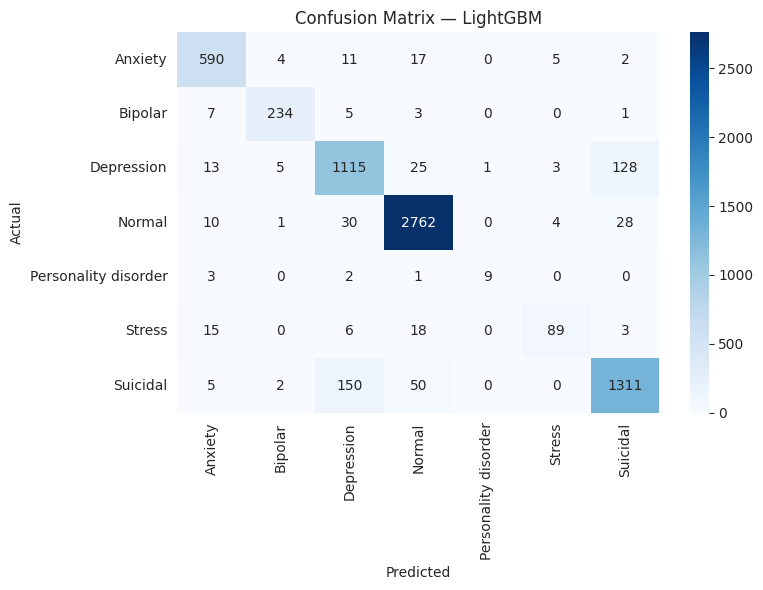

Macro AUC: 0.9893  95% CI [0.9852, 0.9919]
Saved → ./03_SameLabel/outputs/LightGBM_roc_curve.png


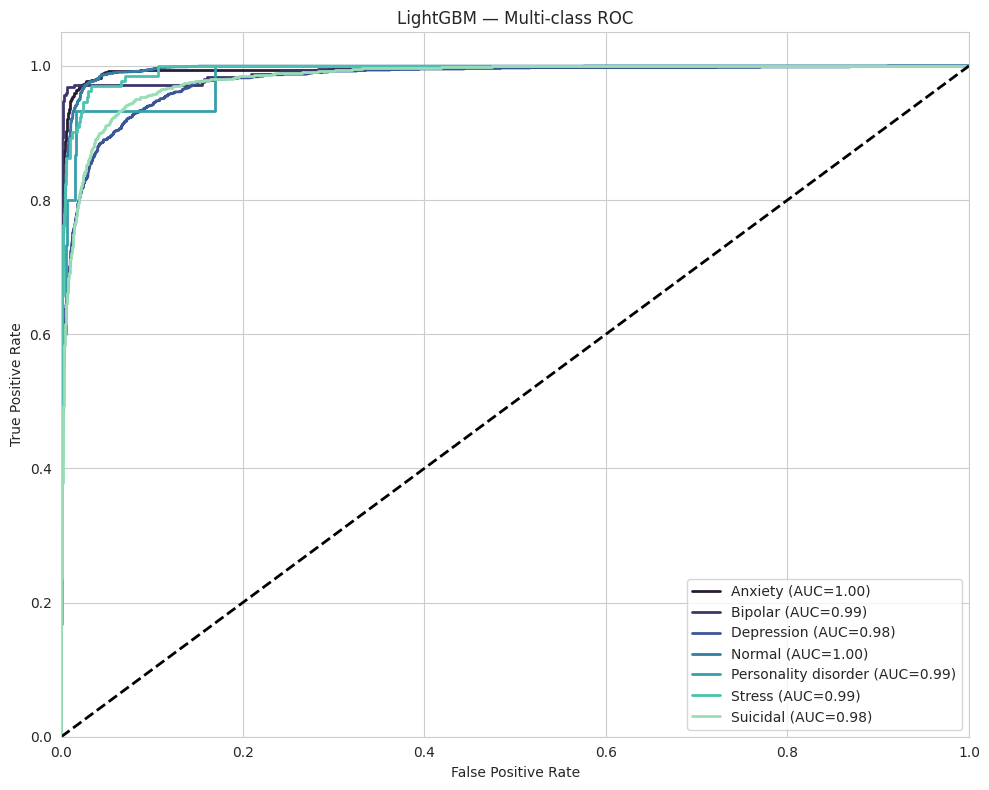

In [ ]:
evaluate_ml(best_model_lgbm, X_test_tfidf, y_test_ml, "LightGBM")

### Step 3: Model Interpretation

Saved → ./03_SameLabel/outputs/lightgbm_feature_importance.png


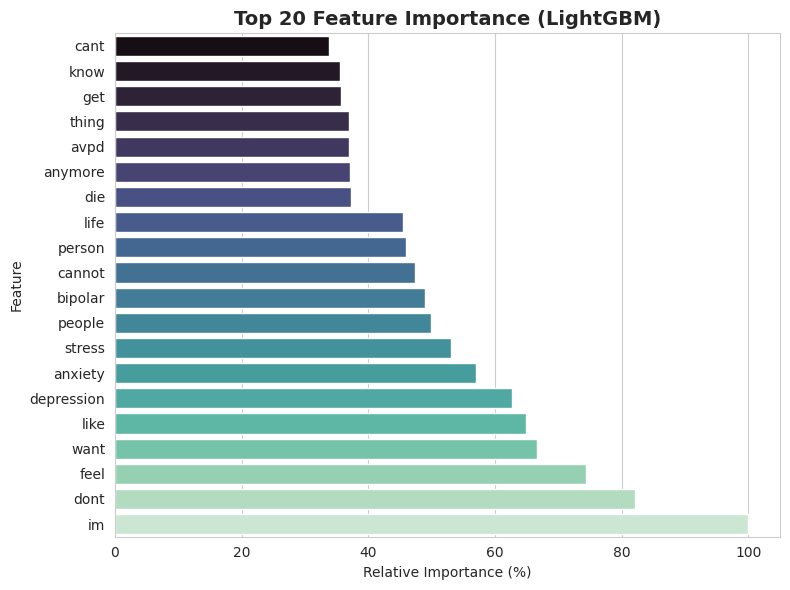

,Feature,Importance,Scaled
4520,im,628,100.000000
2790,dont,516,82.165605
3471,feel,467,74.363057
9626,want,418,66.560510
5243,like,408,64.968153
2466,depression,394,62.738854
645,anxiety,358,57.006369
8527,stress,333,53.025478
6496,people,313,49.840764
1138,bipolar,307,48.885350


In [ ]:
plot_feature_importance(best_model_lgbm.feature_importances_, feature_names_tfidf, "LightGBM")

## 3.4 Save Predictions for Machine Learning Models

In [ ]:
print("\nSaving ML predictions...")

y_true_str = df_test_ml[LABEL_COLUMN].astype(str).values
y_true_id  = label_encoder.transform(y_true_str)

lr_pred   = best_model_lr.predict(X_test_tfidf)
svm_pred  = best_model_svm.predict(X_test_tfidf)
rf_pred   = best_model_rf.predict(X_test_tfidf)
lgbm_pred = best_model_lgbm.predict(X_test_tfidf)

lr_proba   = best_model_lr.predict_proba(X_test_tfidf)
svm_proba  = best_model_svm.predict_proba(X_test_tfidf)
rf_proba   = best_model_rf.predict_proba(X_test_tfidf)
lgbm_proba = best_model_lgbm.predict_proba(X_test_tfidf)

class_names_ml = best_model_lr.classes_
assert np.array_equal(class_names_ml, best_model_svm.classes_)
assert np.array_equal(class_names_ml, best_model_rf.classes_)
assert np.array_equal(class_names_ml, best_model_lgbm.classes_)

# Build prediction DataFrame
if "id" in df_test_ml.columns:
    df_pred_ml = df_test_ml[["id", TEXT_COLUMN]].copy()
else:
    df_pred_ml = df_test_ml[[TEXT_COLUMN]].copy()
    df_pred_ml.insert(0, "id", df_test_ml.index)

df_pred_ml["true_label"]    = y_true_str
df_pred_ml["true_label_id"] = y_true_id
df_pred_ml["lr_pred"]       = lr_pred
df_pred_ml["svm_pred"]      = svm_pred
df_pred_ml["rf_pred"]       = rf_pred
df_pred_ml["lgbm_pred"]     = lgbm_pred

for i, cls in enumerate(class_names_ml):
    df_pred_ml[f"lr_prob_{cls}"]   = lr_proba[:, i]
    df_pred_ml[f"svm_prob_{cls}"]  = svm_proba[:, i]
    df_pred_ml[f"rf_prob_{cls}"]   = rf_proba[:, i]
    df_pred_ml[f"lgbm_prob_{cls}"] = lgbm_proba[:, i]

ml_pred_path = OUTPUT_PATH / "ml_models_predictions.csv"
df_pred_ml.to_csv(ml_pred_path, index=False)
print(f"Saved ML predictions → {ml_pred_path}")


Saving ML predictions...
Saved ML predictions → ./03_SameLabel/outputs/ml_models_predictions.csv


# 4. DL Models


## 4.0 Pre-processing \& data preparation for DL Models

In [ ]:
df_train_dl = df_clean[df_clean["split"] == "train"].copy()
df_val_dl   = df_clean[df_clean["split"] == "val"].copy()
df_test_dl  = df_clean[df_clean["split"] == "test"].copy()

train_labels_dl = df_train_dl[LABEL_COLUMN_ENCODED].tolist()
val_labels_dl   = df_val_dl[LABEL_COLUMN_ENCODED].tolist()
test_labels_dl  = df_test_dl[LABEL_COLUMN_ENCODED].tolist()

# ── GRU/CNN and Transformers all use augmented text (model_text) ──
train_texts_dl = df_train_dl[TEXT_COLUMN].fillna("").astype(str).tolist()
val_texts_dl   = df_val_dl[TEXT_COLUMN].fillna("").astype(str).tolist()
test_texts_dl  = df_test_dl[TEXT_COLUMN].fillna("").astype(str).tolist()

print(f"DL splits: train={len(train_texts_dl)}, val={len(val_texts_dl)}, test={len(test_texts_dl)}")

# ── Build shared vocabulary (GRU + CNN — from raw text) ──
# PAD=0, UNK=1, words start at 2
vocab_counter = Counter()
for text in train_texts_dl:
    vocab_counter.update(text.split())
most_common = [w for w, _ in vocab_counter.most_common(VOCAB_SIZE - 2)]  # -2 for PAD and UNK
word_to_index = {w: i + 2 for i, w in enumerate(most_common)}  # 0=PAD, 1=UNK
UNK_IDX = 1

print(f"Vocabulary: {len(word_to_index)} words + PAD(0) + UNK(1)")


def text_to_sequence(text, w2i, max_len=MAX_TOKEN_LENGTH):
    tokens = text.split()
    return [w2i.get(w, UNK_IDX) for w in tokens][:max_len]


# ── Convert & pad sequences (fixed length = MAX_TOKEN_LENGTH) ──
def build_padded_sequences(texts, w2i, max_len=MAX_TOKEN_LENGTH):
    seqs = []
    for t in texts:
        seq = text_to_sequence(t, w2i, max_len)
        # Pad to exactly max_len (not max-in-split)
        padded = seq + [0] * (max_len - len(seq))
        seqs.append(padded)
    return torch.tensor(seqs, dtype=torch.long)

train_seqs = build_padded_sequences(train_texts_dl, word_to_index)
val_seqs   = build_padded_sequences(val_texts_dl, word_to_index)
test_seqs  = build_padded_sequences(test_texts_dl, word_to_index)

train_labels_t = torch.tensor(train_labels_dl, dtype=torch.long)
val_labels_t   = torch.tensor(val_labels_dl, dtype=torch.long)
test_labels_t  = torch.tensor(test_labels_dl, dtype=torch.long)

print(f"Sequence shapes: train={train_seqs.shape}, val={val_seqs.shape}, test={test_seqs.shape}")

DL splits: train=19924, val=6675, test=6668
Vocabulary: 9998 words + PAD(0) + UNK(1)
Sequence shapes: train=torch.Size([19924, 200]), val=torch.Size([6675, 200]), test=torch.Size([6668, 200])


In [ ]:
# ── Dataset class (GRU + CNN) ────────────────────────────
class SeqDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {"input_ids": self.sequences[idx], "label": self.labels[idx]}


# ── DataLoaders (shared, with pin_memory) ────────────────
_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2,
                  pin_memory=True, persistent_workers=True)

train_loader_seq = DataLoader(SeqDataset(train_seqs, train_labels_t), shuffle=True, **_loader_kw)
val_loader_seq   = DataLoader(SeqDataset(val_seqs, val_labels_t), shuffle=False, **_loader_kw)
test_loader_seq  = DataLoader(SeqDataset(test_seqs, test_labels_t), shuffle=False, **_loader_kw)

# ── Class weights for DL training ────────────────────────
_cw = compute_class_weight("balanced", classes=np.unique(train_labels_dl), y=train_labels_dl)
class_weights_dl = torch.tensor(_cw, dtype=torch.float32).to(DEVICE)

## 4.1 Neural Network (GRU \& CNN)

### 4.1.1 Generic train + evaluation

In [ ]:
def train_seq_model(model, train_loader, val_loader, lr=1e-3,
                    max_epochs=20, patience=5):
    """Train a sequence model (GRU or CNN) with early stopping."""
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_dl)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = GradScaler(enabled=USE_FP16)

    best_f1, best_state, no_improve = -1.0, None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            ids = batch["input_ids"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda", enabled=USE_FP16):
                logits = model(ids)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), SEQ_MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            losses.append(loss.item())

        # Validate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE, non_blocking=True)
                labels = batch["label"]
                with autocast("cuda", enabled=USE_FP16):
                    logits = model(ids)
                val_preds.extend(logits.float().argmax(dim=1).cpu().numpy())
                val_true.extend(labels.numpy())

        val_f1 = f1_score(val_true, val_preds, average="weighted")
        val_acc = accuracy_score(val_true, val_preds)
        print(f"  Epoch {epoch}/{max_epochs} | Loss={np.mean(losses):.4f} | "
              f"Val F1={val_f1:.4f} | Val Acc={val_acc:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    if best_state:
        model.load_state_dict(best_state)
    return best_f1, model

### 4.1.2 GRU

#### Step 1: Define GRU Model

In [ ]:
class GRUSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        _, hidden = self.gru(embedded)
        return self.fc(self.dropout(hidden[-1]))

#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning GRU...")
    start = time.time()

    MAX_EPOCHS_GRU = 20
    PATIENCE_GRU = 5

    gru_param_space = {
        "embedding_dim": (150, 300),
        "hidden_dim": (128, 384),
        "lr": (np.log10(1e-4), np.log10(1e-3)),  # log-uniform
    }

    best_f1_gru, best_params_gru, best_gru = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="GRU Random Search"):
        hp = {
            "embedding_dim": int(np.random.uniform(*gru_param_space["embedding_dim"])),
            "hidden_dim": int(np.random.uniform(*gru_param_space["hidden_dim"])),
            "lr": float(10 ** np.random.uniform(*gru_param_space["lr"])),
        }

        model = GRUSentimentModel(
            vocab_size=VOCAB_SIZE, embedding_dim=hp["embedding_dim"],
            hidden_dim=hp["hidden_dim"], output_dim=NUM_CLASSES,
        )

        f1_val, model = train_seq_model(
            model, train_loader_seq, val_loader_seq,
            lr=hp["lr"], max_epochs=MAX_EPOCHS_GRU, patience=PATIENCE_GRU,
        )

        if f1_val > best_f1_gru:
            best_f1_gru = f1_val
            best_params_gru = hp
            best_gru = model

    print(f"GRU tuning: {time.time()-start:.1f}s | Best F1={best_f1_gru:.4f}")
    print(f"Best params: {best_params_gru}")

    torch.save(best_gru.state_dict(), MODEL_PATHS["gru"]["model"])
    with open(MODEL_PATHS["gru"]["params"], "w") as f:
        json.dump(best_params_gru, f, indent=2)
else:
    print("Loading GRU from disk...")
    with open(MODEL_PATHS["gru"]["params"]) as f:
        best_params_gru = json.load(f)
    best_gru = GRUSentimentModel(
        vocab_size=VOCAB_SIZE, embedding_dim=int(best_params_gru["embedding_dim"]),
        hidden_dim=int(best_params_gru["hidden_dim"]), output_dim=NUM_CLASSES,
    )
    best_gru.load_state_dict(torch.load(MODEL_PATHS["gru"]["model"], map_location=DEVICE))
    print(f"Loaded GRU from {MODEL_PATHS['gru']['model']}")



Tuning GRU...


GRU Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1/20 | Loss=1.9127 | Val F1=0.3593 | Val Acc=0.4761
  Epoch 2/20 | Loss=1.8070 | Val F1=0.3613 | Val Acc=0.4761
  Epoch 3/20 | Loss=1.6539 | Val F1=0.5956 | Val Acc=0.6342
  Epoch 4/20 | Loss=1.2268 | Val F1=0.6494 | Val Acc=0.6469
  Epoch 5/20 | Loss=0.9608 | Val F1=0.7005 | Val Acc=0.6818
  Epoch 6/20 | Loss=0.6468 | Val F1=0.8057 | Val Acc=0.7982
  Epoch 7/20 | Loss=0.4221 | Val F1=0.8300 | Val Acc=0.8106
  Epoch 8/20 | Loss=0.2759 | Val F1=0.8458 | Val Acc=0.8442
  Epoch 9/20 | Loss=0.2095 | Val F1=0.8688 | Val Acc=0.8664
  Epoch 10/20 | Loss=0.1338 | Val F1=0.8616 | Val Acc=0.8623
  Epoch 11/20 | Loss=0.1054 | Val F1=0.8617 | Val Acc=0.8611
  Epoch 12/20 | Loss=0.1023 | Val F1=0.8725 | Val Acc=0.8740
  Epoch 13/20 | Loss=0.0604 | Val F1=0.8701 | Val Acc=0.8662
  Epoch 14/20 | Loss=0.0375 | Val F1=0.8753 | Val Acc=0.8761
  Epoch 15/20 | Loss=0.0275 | Val F1=0.8790 | Val Acc=0.8791
  Epoch 16/20 | Loss=0.0189 | Val F1=0.8726 | Val Acc=0.8754
  Epoch 17/20 | Loss=0.0130 | Val

GRU Random Search:  10%|█         | 1/10 [00:39<05:55, 39.52s/it]

  Epoch 20/20 | Loss=0.0387 | Val F1=0.8735 | Val Acc=0.8742
  Early stopping at epoch 20.
  Epoch 1/20 | Loss=1.9335 | Val F1=0.3509 | Val Acc=0.4737
  Epoch 2/20 | Loss=1.8613 | Val F1=0.3348 | Val Acc=0.4616
  Epoch 3/20 | Loss=1.8333 | Val F1=0.1985 | Val Acc=0.1497
  Epoch 4/20 | Loss=1.7097 | Val F1=0.4285 | Val Acc=0.4644
  Epoch 5/20 | Loss=1.5806 | Val F1=0.5186 | Val Acc=0.5104
  Epoch 6/20 | Loss=1.5299 | Val F1=0.5258 | Val Acc=0.5151
  Epoch 7/20 | Loss=1.4807 | Val F1=0.5371 | Val Acc=0.5390
  Epoch 8/20 | Loss=1.4322 | Val F1=0.5857 | Val Acc=0.6012
  Epoch 9/20 | Loss=1.3591 | Val F1=0.6058 | Val Acc=0.6226
  Epoch 10/20 | Loss=1.2537 | Val F1=0.6210 | Val Acc=0.6259
  Epoch 11/20 | Loss=1.1072 | Val F1=0.6297 | Val Acc=0.6340
  Epoch 12/20 | Loss=0.9948 | Val F1=0.6841 | Val Acc=0.6709
  Epoch 13/20 | Loss=0.9685 | Val F1=0.6499 | Val Acc=0.6638
  Epoch 14/20 | Loss=0.9100 | Val F1=0.6758 | Val Acc=0.6843
  Epoch 15/20 | Loss=0.8105 | Val F1=0.6830 | Val Acc=0.6905
  E

...

  Epoch 20/20 | Loss=0.7211 | Val F1=0.7387 | Val Acc=0.7279
  Epoch 1/20 | Loss=1.9151 | Val F1=0.3396 | Val Acc=0.4644
  Epoch 2/20 | Loss=1.8182 | Val F1=0.3658 | Val Acc=0.4767
  Epoch 3/20 | Loss=1.7378 | Val F1=0.3795 | Val Acc=0.4894
  Epoch 4/20 | Loss=1.5778 | Val F1=0.4852 | Val Acc=0.4884
  Epoch 5/20 | Loss=1.4541 | Val F1=0.5917 | Val Acc=0.6210
  Epoch 6/20 | Loss=1.2756 | Val F1=0.6171 | Val Acc=0.6294
  Epoch 7/20 | Loss=1.1156 | Val F1=0.6250 | Val Acc=0.6334
  Epoch 8/20 | Loss=1.0323 | Val F1=0.6804 | Val Acc=0.6781
  Epoch 9/20 | Loss=1.0107 | Val F1=0.6762 | Val Acc=0.6748
  Epoch 10/20 | Loss=0.8493 | Val F1=0.7266 | Val Acc=0.7350
  Epoch 11/20 | Loss=0.7637 | Val F1=0.7537 | Val Acc=0.7350
  Epoch 12/20 | Loss=0.6510 | Val F1=0.7864 | Val Acc=0.7847
  Epoch 13/20 | Loss=0.5979 | Val F1=0.7823 | Val Acc=0.7813
  Epoch 14/20 | Loss=0.4972 | Val F1=0.7964 | Val Acc=0.7850
  Epoch 15/20 | Loss=0.4635 | Val F1=0.8050 | Val Acc=0.7858
  Epoch 16/20 | Loss=0.3975 | Val

GRU Random Search:  90%|█████████ | 9/10 [05:33<00:38, 38.18s/it]

  Epoch 20/20 | Loss=0.2394 | Val F1=0.8439 | Val Acc=0.8358
  Epoch 1/20 | Loss=1.9434 | Val F1=0.3471 | Val Acc=0.4682
  Epoch 2/20 | Loss=1.9107 | Val F1=0.3577 | Val Acc=0.4761
  Epoch 3/20 | Loss=1.8754 | Val F1=0.3589 | Val Acc=0.4793
  Epoch 4/20 | Loss=1.8456 | Val F1=0.3573 | Val Acc=0.4790
  Epoch 5/20 | Loss=1.8177 | Val F1=0.3686 | Val Acc=0.4864
  Epoch 6/20 | Loss=1.7630 | Val F1=0.4836 | Val Acc=0.5509
  Epoch 7/20 | Loss=1.6380 | Val F1=0.4746 | Val Acc=0.5221
  Epoch 8/20 | Loss=1.5821 | Val F1=0.5058 | Val Acc=0.5230
  Epoch 9/20 | Loss=1.5741 | Val F1=0.4881 | Val Acc=0.5061
  Epoch 10/20 | Loss=1.5257 | Val F1=0.4784 | Val Acc=0.4470
  Epoch 11/20 | Loss=1.4952 | Val F1=0.5375 | Val Acc=0.5190
  Epoch 12/20 | Loss=1.4683 | Val F1=0.5302 | Val Acc=0.5410
  Epoch 13/20 | Loss=1.4410 | Val F1=0.5126 | Val Acc=0.4900
  Epoch 14/20 | Loss=1.4157 | Val F1=0.5440 | Val Acc=0.5291
  Epoch 15/20 | Loss=1.3998 | Val F1=0.5686 | Val Acc=0.5540
  Epoch 16/20 | Loss=1.3663 | Val

GRU Random Search: 100%|██████████| 10/10 [06:17<00:00, 37.74s/it]

  Epoch 20/20 | Loss=1.1804 | Val F1=0.5762 | Val Acc=0.5476
GRU tuning: 377.4s | Best F1=0.8790
Best params: {'embedding_dim': 170, 'hidden_dim': 355, 'lr': 0.0008562599671988812}


#### Step 3: Model Evaluation

Eval GRU: 100%|██████████| 53/53 [00:00<00:00, 156.21it/s]



Evaluation: GRU
                      precision    recall  f1-score   support

             Anxiety     0.8785    0.9078    0.8929       629
              Normal     0.9614    0.9573    0.9593      2835
          Depression     0.7621    0.8442    0.8010      1290
            Suicidal     0.8698    0.8057    0.8365      1518
              Stress     0.5354    0.5191    0.5271       131
             Bipolar     0.9414    0.8360    0.8856       250
Personality disorder     0.2727    0.2000    0.2308        15

            accuracy                         0.8814      6668
           macro avg     0.7459    0.7243    0.7333      6668
        weighted avg     0.8835    0.8814    0.8816      6668

Weighted F1: 0.8816  95% CI [0.8742, 0.8896]
Saved → ./03_SameLabel/outputs/GRU_confusion_matrix.png


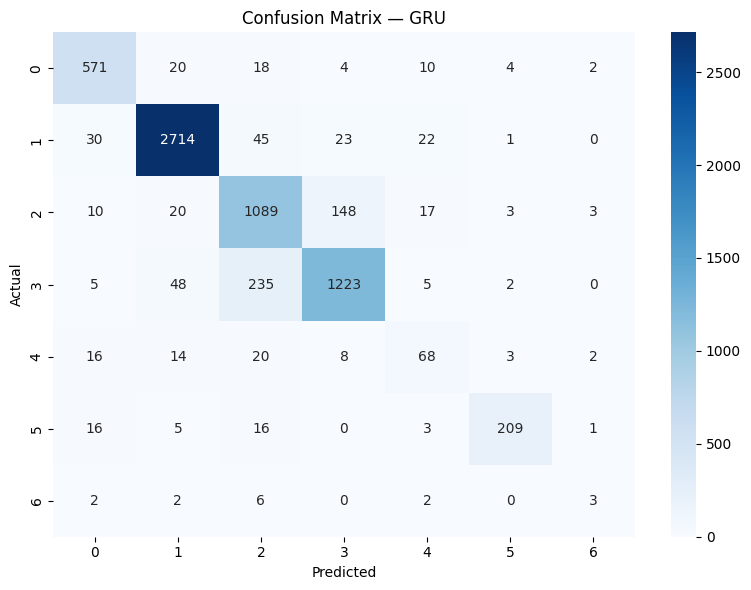

Macro AUC: 0.9717  95% CI [0.9647, 0.9776]
Saved → ./03_SameLabel/outputs/GRU_roc_curve.png


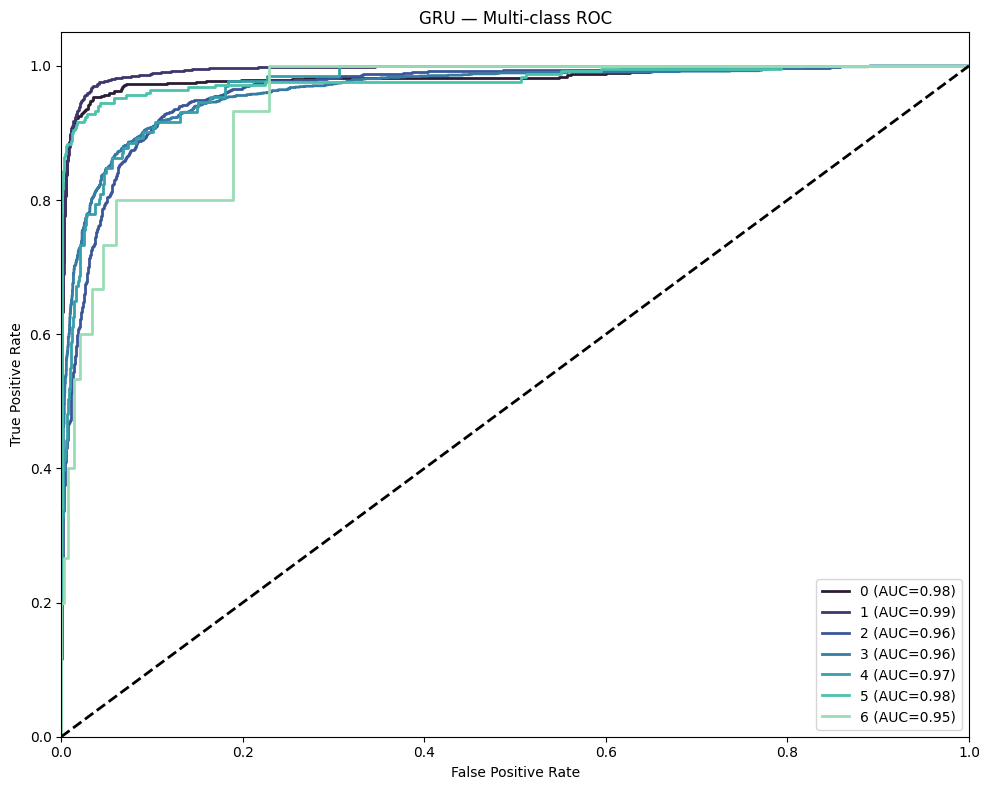

In [ ]:
gru_preds, gru_probs, y_true_gru = evaluate_pytorch(
    best_gru, test_loader_seq, label_encoder, "GRU", use_attention_mask=False
)

### 4.1.3 CNN

### 4.2.2 CNN Modeling

#### Step 1: Define CNN Model

In [ ]:
class CNNSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_filters, filter_sizes,
                 output_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embedding_dim, num_filters, fs) for fs in filter_sizes
        ])
        self.fc = nn.Linear(num_filters * len(filter_sizes), output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        x = self.embedding(input_ids).permute(0, 2, 1)  # [B, E, L]
        pooled = [torch.relu(conv(x)).max(dim=2).values for conv in self.convs]
        cat = torch.cat(pooled, dim=1)
        return self.fc(self.dropout(cat))

#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

FILTER_SIZES = [3, 4, 5]

if RETRAIN:
    set_seed()
    print("\nTuning CNN...")
    start = time.time()

    MAX_EPOCHS_CNN = 20
    PATIENCE_CNN = 5

    cnn_param_space = {
        "embedding_dim": (150, 300),     # uniform
        "num_filters":  (80, 200),       # filters per kernel size
        "lr": (np.log10(1e-4), np.log10(1e-3)),  # log-uniform
    }

    best_f1_cnn, best_params_cnn, best_cnn = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="CNN Random Search"):
        hp = {
            "embedding_dim": int(np.random.uniform(*cnn_param_space["embedding_dim"])),
            "num_filters": int(np.random.uniform(*cnn_param_space["num_filters"])),
            "lr": float(10 ** np.random.uniform(*cnn_param_space["lr"])),
        }

        model = CNNSentimentModel(
            vocab_size=VOCAB_SIZE, embedding_dim=hp["embedding_dim"],
            num_filters=hp["num_filters"], filter_sizes=FILTER_SIZES,
            output_dim=NUM_CLASSES,
        )

        f1_val, model = train_seq_model(
            model, train_loader_seq, val_loader_seq,
            lr=hp["lr"], max_epochs=MAX_EPOCHS_CNN, patience=PATIENCE_CNN,
        )

        if f1_val > best_f1_cnn:
            best_f1_cnn = f1_val
            best_params_cnn = hp
            best_cnn = model

    print(f"CNN tuning: {time.time()-start:.1f}s | Best F1={best_f1_cnn:.4f}")
    print(f"Best params: {best_params_cnn}")

    torch.save(best_cnn.state_dict(), MODEL_PATHS["cnn"]["model"])
    with open(MODEL_PATHS["cnn"]["params"], "w") as f:
        json.dump(best_params_cnn, f, indent=2)
else:
    print("Loading CNN from disk...")
    with open(MODEL_PATHS["cnn"]["params"]) as f:
        best_params_cnn = json.load(f)
    best_cnn = CNNSentimentModel(
        vocab_size=VOCAB_SIZE, embedding_dim=int(best_params_cnn["embedding_dim"]),
        num_filters=int(best_params_cnn["num_filters"]), filter_sizes=FILTER_SIZES,
        output_dim=NUM_CLASSES,
    )
    best_cnn.load_state_dict(torch.load(MODEL_PATHS["cnn"]["model"], map_location=DEVICE))
    print(f"Loaded CNN from {MODEL_PATHS['cnn']['model']}")


Tuning CNN...


CNN Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1/20 | Loss=1.4352 | Val F1=0.7913 | Val Acc=0.7787
  Epoch 2/20 | Loss=0.6464 | Val F1=0.8567 | Val Acc=0.8581
  Epoch 3/20 | Loss=0.4058 | Val F1=0.8739 | Val Acc=0.8752
  Epoch 4/20 | Loss=0.2600 | Val F1=0.8912 | Val Acc=0.8905
  Epoch 5/20 | Loss=0.2154 | Val F1=0.8905 | Val Acc=0.8881
  Epoch 6/20 | Loss=0.1710 | Val F1=0.8887 | Val Acc=0.8879
  Epoch 7/20 | Loss=0.1446 | Val F1=0.8909 | Val Acc=0.8914
  Epoch 8/20 | Loss=0.1241 | Val F1=0.8974 | Val Acc=0.8947
  Epoch 9/20 | Loss=0.1070 | Val F1=0.8980 | Val Acc=0.8990
  Epoch 10/20 | Loss=0.0835 | Val F1=0.9008 | Val Acc=0.9011
  Epoch 11/20 | Loss=0.0860 | Val F1=0.8973 | Val Acc=0.8987
  Epoch 12/20 | Loss=0.0737 | Val F1=0.8820 | Val Acc=0.8828
  Epoch 13/20 | Loss=0.0688 | Val F1=0.9009 | Val Acc=0.9014
  Epoch 14/20 | Loss=0.0525 | Val F1=0.8996 | Val Acc=0.9002
  Epoch 15/20 | Loss=0.0411 | Val F1=0.9002 | Val Acc=0.9002
  Epoch 16/20 | Loss=0.0354 | Val F1=0.9074 | Val Acc=0.9067
  Epoch 17/20 | Loss=0.0355 | Val

CNN Random Search:  10%|█         | 1/10 [00:18<02:45, 18.43s/it]

  Epoch 20/20 | Loss=0.0323 | Val F1=0.9009 | Val Acc=0.9011
  Epoch 1/20 | Loss=1.8191 | Val F1=0.6786 | Val Acc=0.6515
  Epoch 2/20 | Loss=1.2255 | Val F1=0.7685 | Val Acc=0.7579
  Epoch 3/20 | Loss=0.9185 | Val F1=0.7940 | Val Acc=0.7880
  Epoch 4/20 | Loss=0.7036 | Val F1=0.8168 | Val Acc=0.8171
  Epoch 5/20 | Loss=0.6011 | Val F1=0.8257 | Val Acc=0.8237
  Epoch 6/20 | Loss=0.4968 | Val F1=0.8388 | Val Acc=0.8393
  Epoch 7/20 | Loss=0.4281 | Val F1=0.8545 | Val Acc=0.8527
  Epoch 8/20 | Loss=0.3745 | Val F1=0.8629 | Val Acc=0.8634
  Epoch 9/20 | Loss=0.3328 | Val F1=0.8692 | Val Acc=0.8689
  Epoch 10/20 | Loss=0.3009 | Val F1=0.8745 | Val Acc=0.8728
  Epoch 11/20 | Loss=0.2648 | Val F1=0.8748 | Val Acc=0.8748
  Epoch 12/20 | Loss=0.2497 | Val F1=0.8801 | Val Acc=0.8797
  Epoch 13/20 | Loss=0.2288 | Val F1=0.8808 | Val Acc=0.8809
  Epoch 14/20 | Loss=0.2109 | Val F1=0.8856 | Val Acc=0.8863
  Epoch 15/20 | Loss=0.1931 | Val F1=0.8860 | Val Acc=0.8855
  Epoch 16/20 | Loss=0.1805 | Val

...

  Epoch 20/20 | Loss=0.1351 | Val F1=0.8945 | Val Acc=0.8945
  Epoch 1/20 | Loss=1.7312 | Val F1=0.7105 | Val Acc=0.7049
  Epoch 2/20 | Loss=1.0400 | Val F1=0.7911 | Val Acc=0.7886
  Epoch 3/20 | Loss=0.6942 | Val F1=0.8393 | Val Acc=0.8364
  Epoch 4/20 | Loss=0.5107 | Val F1=0.8468 | Val Acc=0.8457
  Epoch 5/20 | Loss=0.3831 | Val F1=0.8640 | Val Acc=0.8656
  Epoch 6/20 | Loss=0.3065 | Val F1=0.8802 | Val Acc=0.8796
  Epoch 7/20 | Loss=0.2669 | Val F1=0.8834 | Val Acc=0.8821
  Epoch 8/20 | Loss=0.2267 | Val F1=0.8853 | Val Acc=0.8857
  Epoch 9/20 | Loss=0.1930 | Val F1=0.8879 | Val Acc=0.8887
  Epoch 10/20 | Loss=0.1789 | Val F1=0.8918 | Val Acc=0.8926
  Epoch 11/20 | Loss=0.1567 | Val F1=0.8934 | Val Acc=0.8942
  Epoch 12/20 | Loss=0.1443 | Val F1=0.8916 | Val Acc=0.8929
  Epoch 13/20 | Loss=0.1231 | Val F1=0.8959 | Val Acc=0.8968
  Epoch 14/20 | Loss=0.1160 | Val F1=0.8983 | Val Acc=0.8989
  Epoch 15/20 | Loss=0.1027 | Val F1=0.9003 | Val Acc=0.9005
  Epoch 16/20 | Loss=0.0952 | Val

CNN Random Search:  90%|█████████ | 9/10 [02:39<00:17, 18.00s/it]

  Epoch 20/20 | Loss=0.0673 | Val F1=0.9001 | Val Acc=0.9004
  Epoch 1/20 | Loss=1.9222 | Val F1=0.5561 | Val Acc=0.5257
  Epoch 2/20 | Loss=1.5698 | Val F1=0.6568 | Val Acc=0.6491
  Epoch 3/20 | Loss=1.2817 | Val F1=0.7346 | Val Acc=0.7308
  Epoch 4/20 | Loss=1.0920 | Val F1=0.7590 | Val Acc=0.7512
  Epoch 5/20 | Loss=0.9053 | Val F1=0.7889 | Val Acc=0.7892
  Epoch 6/20 | Loss=0.7882 | Val F1=0.8056 | Val Acc=0.8021
  Epoch 7/20 | Loss=0.6990 | Val F1=0.8140 | Val Acc=0.8129
  Epoch 8/20 | Loss=0.6363 | Val F1=0.8231 | Val Acc=0.8217
  Epoch 9/20 | Loss=0.5556 | Val F1=0.8290 | Val Acc=0.8267
  Epoch 10/20 | Loss=0.5125 | Val F1=0.8378 | Val Acc=0.8358
  Epoch 11/20 | Loss=0.4724 | Val F1=0.8467 | Val Acc=0.8461
  Epoch 12/20 | Loss=0.4410 | Val F1=0.8539 | Val Acc=0.8529
  Epoch 13/20 | Loss=0.4158 | Val F1=0.8564 | Val Acc=0.8566
  Epoch 14/20 | Loss=0.3930 | Val F1=0.8639 | Val Acc=0.8637
  Epoch 15/20 | Loss=0.3479 | Val F1=0.8711 | Val Acc=0.8706
  Epoch 16/20 | Loss=0.3389 | Val

CNN Random Search: 100%|██████████| 10/10 [02:57<00:00, 17.75s/it]

  Epoch 20/20 | Loss=0.2743 | Val F1=0.8832 | Val Acc=0.8828
CNN tuning: 177.5s | Best F1=0.9074
Best params: {'embedding_dim': 170, 'num_filters': 186, 'lr': 0.0008562599671988812}


#### Step 3: Model Evaluation

Eval CNN: 100%|██████████| 53/53 [00:00<00:00, 398.48it/s]


Evaluation: CNN
                      precision    recall  f1-score   support

             Anxiety     0.9072    0.9173    0.9123       629
              Normal     0.9706    0.9668    0.9687      2835
          Depression     0.8309    0.8457    0.8383      1290
            Suicidal     0.8817    0.8491    0.8651      1518
              Stress     0.6556    0.9008    0.7588       131
             Bipolar     0.9467    0.9240    0.9352       250
Personality disorder     1.0000    0.6000    0.7500        15

            accuracy                         0.9082      6668
           macro avg     0.8847    0.8577    0.8612      6668
        weighted avg     0.9103    0.9082    0.9087      6668



Weighted F1: 0.9087  95% CI [0.9015, 0.9158]
Saved → ./03_SameLabel/outputs/CNN_confusion_matrix.png


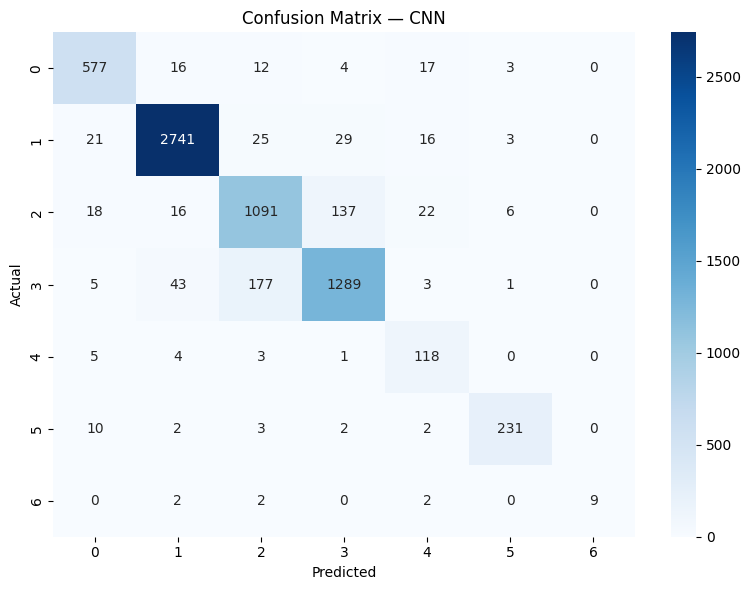

Macro AUC: 0.9874  95% CI [0.9829, 0.9904]
Saved → ./03_SameLabel/outputs/CNN_roc_curve.png


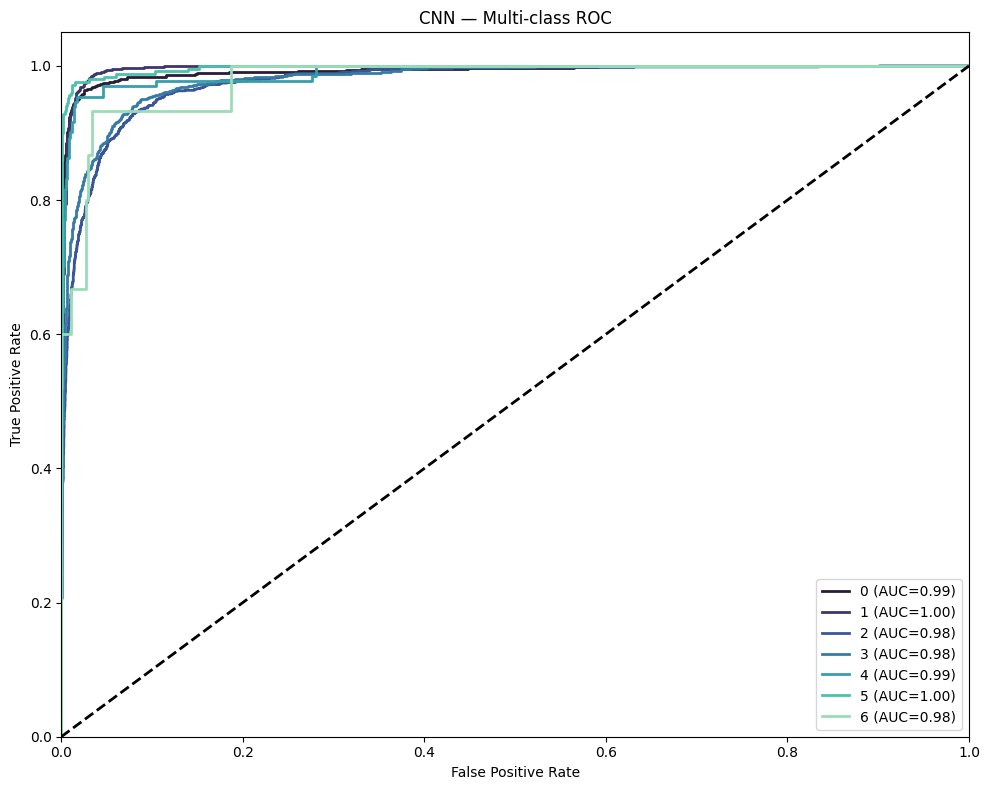

In [ ]:
cnn_preds, cnn_probs, y_true_cnn = evaluate_pytorch(
    best_cnn, test_loader_seq, label_encoder, "CNN", use_attention_mask=False
)

## 4.2 Transformer

### 4.2.1 Generic transformer train function

In [ ]:
def train_transformer(model, train_loader, val_loader,
                      lr=2e-5, max_epochs=6, patience=2):
    """Fine-tune a HuggingFace transformer with FP16, grad clip, OneCycleLR."""
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    total_steps = max_epochs * len(train_loader)
    scheduler = OneCycleLR(optimizer, max_lr=lr, total_steps=total_steps, pct_start=0.1)
    criterion = nn.CrossEntropyLoss(weight=class_weights_dl)
    scaler = GradScaler(enabled=USE_FP16)

    best_f1, best_state, no_improve = -1.0, None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids, attention_mask=mask)
                logits = outputs.logits if hasattr(outputs, "logits") else outputs
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            losses.append(loss.item())

        # Validate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
                mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
                with autocast("cuda", enabled=USE_FP16):
                    out = model(input_ids=ids, attention_mask=mask)
                logits = out.logits if hasattr(out, "logits") else out
                val_preds.extend(logits.float().argmax(dim=1).cpu().numpy())
                val_true.extend(batch["label"].numpy())

        val_f1 = f1_score(val_true, val_preds, average="weighted")
        print(f"  Epoch {epoch}/{max_epochs} | Loss={np.mean(losses):.4f} | Val F1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            raw = model._orig_mod if hasattr(model, "_orig_mod") else model
            best_state = {k: v.cpu().clone() for k, v in raw.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    raw = model._orig_mod if hasattr(model, "_orig_mod") else model
    if best_state:
        raw.load_state_dict(best_state)
    return best_f1, raw

### 4.2.2 ALBERT

#### Step 1: Data Preparation

In [ ]:
print("\nPre-tokenizing for ALBERT...")
albert_tokenizer = AutoTokenizer.from_pretrained("albert-base-v2")


def batch_tokenize(texts, tokenizer, max_len, batch_size=512):
    all_ids, all_masks = [], []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(
            texts[i:i+batch_size], max_length=max_len,
            truncation=True, padding="max_length", return_tensors="pt",
        )
        all_ids.append(enc["input_ids"])
        all_masks.append(enc["attention_mask"])
    return torch.cat(all_ids), torch.cat(all_masks)


# Use same text lists as DL
train_ids_albert, train_masks_albert = batch_tokenize(train_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
val_ids_albert, val_masks_albert     = batch_tokenize(val_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
test_ids_albert, test_masks_albert   = batch_tokenize(test_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
print(f"ALBERT tokens: train={train_ids_albert.shape}")


# ── Cached dataset for transformers ──────────────────────
class TransformerDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = torch.tensor(np.asarray(labels, dtype=np.int64))

    def __len__(self):
        return self.input_ids.shape[0]

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "label": self.labels[idx],
        }


_tf_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2,
                     pin_memory=True, persistent_workers=True, prefetch_factor=4)

train_loader_albert = DataLoader(
    TransformerDataset(train_ids_albert, train_masks_albert, train_labels_dl),
    shuffle=True, **_tf_loader_kw)
val_loader_albert = DataLoader(
    TransformerDataset(val_ids_albert, val_masks_albert, val_labels_dl),
    shuffle=False, **_tf_loader_kw)
test_loader_albert = DataLoader(
    TransformerDataset(test_ids_albert, test_masks_albert, test_labels_dl),
    shuffle=False, **_tf_loader_kw)


Pre-tokenizing for ALBERT...


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

ALBERT tokens: train=torch.Size([19924, 200])


#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

if RETRAIN:
    set_seed()
    print("\nTuning ALBERT...")
    start = time.time()

    albert_param_space = {
        "lr": (np.log10(1e-5), np.log10(3e-5)),
        "epochs": (4, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_albert, best_params_albert, best_albert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="ALBERT Random Search"):
        hp = {
            "lr": float(10 ** np.random.uniform(*albert_param_space["lr"])),
            "epochs": int(np.random.randint(*albert_param_space["epochs"])),
            "dropout": float(np.random.uniform(*albert_param_space["dropout"])),
        }

        model = AlbertForSequenceClassification.from_pretrained(
            "albert-base-v2", num_labels=NUM_CLASSES,
            classifier_dropout_prob=hp["dropout"],
        )

        if TORCH_COMPILE_OK:
            model = torch.compile(model, mode="reduce-overhead")

        f1_val, model = train_transformer(
            model, train_loader_albert, val_loader_albert,
            lr=hp["lr"], max_epochs=hp["epochs"], patience=3,
        )

        if f1_val > best_f1_albert:
            best_f1_albert = f1_val
            best_params_albert = hp
            best_albert = model

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"ALBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_albert:.4f}")
    print(f"Best params: {best_params_albert}")

    torch.save(best_albert.state_dict(), MODEL_PATHS["albert"]["model"])
else:
    print("Loading ALBERT from disk...")
    best_albert = AlbertForSequenceClassification.from_pretrained(
        "albert-base-v2", num_labels=NUM_CLASSES,
    )
    best_albert.load_state_dict(torch.load(MODEL_PATHS["albert"]["model"], map_location=DEVICE))
    print(f"Loaded ALBERT from {MODEL_PATHS['albert']['model']}")


Tuning ALBERT...


ALBERT Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/9 | Loss=1.4510 | Val F1=0.8809
  Epoch 2/9 | Loss=0.3793 | Val F1=0.8946
  Epoch 3/9 | Loss=0.2023 | Val F1=0.9219
  Epoch 4/9 | Loss=0.1253 | Val F1=0.9379
  Epoch 5/9 | Loss=0.0679 | Val F1=0.9312
  Epoch 6/9 | Loss=0.0347 | Val F1=0.9364
  Epoch 7/9 | Loss=0.0156 | Val F1=0.9363
  Early stopping at epoch 7.


ALBERT Random Search: 100%|██████████| 10/10 [38:41<00:00, 232.11s/it]

ALBERT tuning: 2321.1s | Best F1=0.9379
Best params: {'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.2365358833708563}


#### Step 3: Model Evaluation

Eval ALBERT: 100%|██████████| 53/53 [00:04<00:00, 12.02it/s]



Evaluation: ALBERT
                      precision    recall  f1-score   support

             Anxiety     0.9219    0.9762    0.9483       629
              Normal     0.9756    0.9866    0.9811      2835
          Depression     0.8927    0.8767    0.8846      1290
            Suicidal     0.9200    0.8860    0.9027      1518
              Stress     0.8284    0.8473    0.8377       131
             Bipolar     0.9389    0.9840    0.9609       250
Personality disorder     0.9000    0.6000    0.7200        15

            accuracy                         0.9378      6668
           macro avg     0.9111    0.8796    0.8908      6668
        weighted avg     0.9374    0.9378    0.9373      6668

Weighted F1: 0.9374  95% CI [0.9313, 0.9433]
Saved → ./03_SameLabel/outputs/ALBERT_confusion_matrix.png


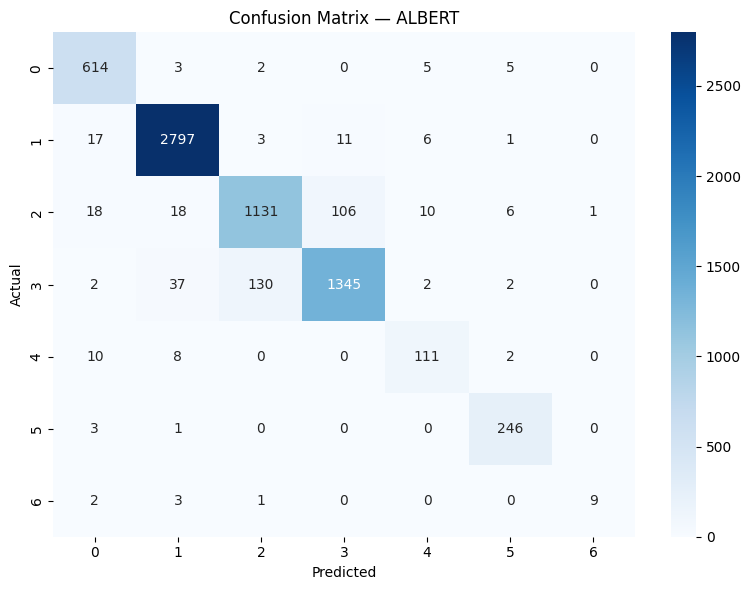

Macro AUC: 0.9942  95% CI [0.9927, 0.9954]
Saved → ./03_SameLabel/outputs/ALBERT_roc_curve.png


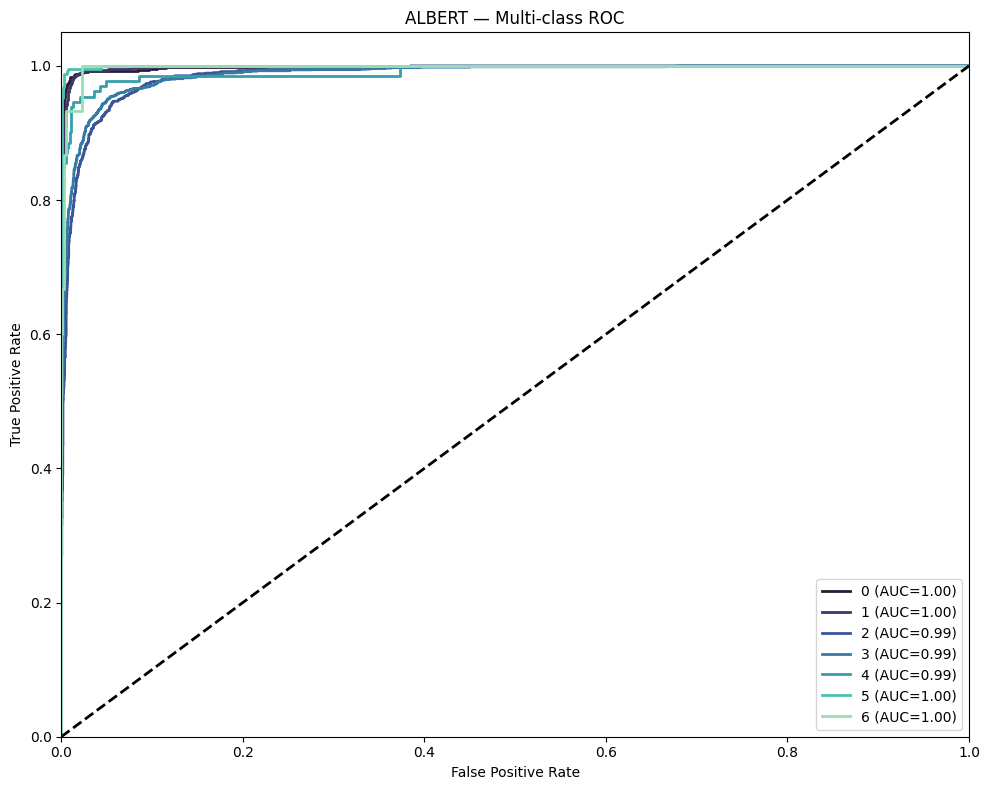

In [ ]:
albert_preds, albert_probs, y_true_albert = evaluate_pytorch(
    best_albert, test_loader_albert, label_encoder, "ALBERT", use_attention_mask=True
)

### 4.4.3 BioBERT Modeling

#### Step 1: Data Preparation

In [ ]:
print("\nPre-tokenizing for BioBERT...")
biobert_name = "dmis-lab/biobert-v1.1"
biobert_tokenizer = AutoTokenizer.from_pretrained(biobert_name)

train_ids_bio, train_masks_bio = batch_tokenize(train_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
val_ids_bio, val_masks_bio     = batch_tokenize(val_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
test_ids_bio, test_masks_bio   = batch_tokenize(test_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
print(f"BioBERT tokens: train={train_ids_bio.shape}")

train_loader_biobert = DataLoader(
    TransformerDataset(train_ids_bio, train_masks_bio, train_labels_dl),
    shuffle=True, **_tf_loader_kw)
val_loader_biobert = DataLoader(
    TransformerDataset(val_ids_bio, val_masks_bio, val_labels_dl),
    shuffle=False, **_tf_loader_kw)
test_loader_biobert = DataLoader(
    TransformerDataset(test_ids_bio, test_masks_bio, test_labels_dl),
    shuffle=False, **_tf_loader_kw)


Pre-tokenizing for BioBERT...


config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

BioBERT tokens: train=torch.Size([19924, 200])


#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

if RETRAIN:
    set_seed()
    print("\nTuning BioBERT...")
    start = time.time()

    biobert_param_space = {
        "lr": (np.log10(1e-5), np.log10(3e-5)),
        "epochs": (4, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_biobert, best_params_biobert, best_biobert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="BioBERT Random Search"):
        hp = {
            "lr": float(10 ** np.random.uniform(*biobert_param_space["lr"])),
            "epochs": int(np.random.randint(*biobert_param_space["epochs"])),
            "dropout": float(np.random.uniform(*biobert_param_space["dropout"])),
        }

        model = AutoModelForSequenceClassification.from_pretrained(
            biobert_name, num_labels=NUM_CLASSES,
        )
        model.config.hidden_dropout_prob = hp["dropout"]
        model.config.attention_probs_dropout_prob = hp["dropout"]

        if TORCH_COMPILE_OK:
            model = torch.compile(model, mode="reduce-overhead")

        f1_val, model = train_transformer(
            model, train_loader_biobert, val_loader_biobert,
            lr=hp["lr"], max_epochs=hp["epochs"], patience=3,
        )

        if f1_val > best_f1_biobert:
            best_f1_biobert = f1_val
            best_params_biobert = hp
            best_biobert = model

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"BioBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_biobert:.4f}")
    print(f"Best params: {best_params_biobert}")

    torch.save(best_biobert.state_dict(), MODEL_PATHS["biobert"]["model"])
else:
    print("Loading BioBERT from disk...")
    best_biobert = AutoModelForSequenceClassification.from_pretrained(
        biobert_name, num_labels=NUM_CLASSES,
    )
    best_biobert.load_state_dict(torch.load(MODEL_PATHS["biobert"]["model"], map_location=DEVICE))
    print(f"Loaded BioBERT from {MODEL_PATHS['biobert']['model']}")



Tuning BioBERT...


BioBERT Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-v1.1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-v1.1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/9 | Loss=1.5281 | Val F1=0.7821
  Epoch 2/9 | Loss=0.4056 | Val F1=0.8897
  Epoch 3/9 | Loss=0.2170 | Val F1=0.9090
  Epoch 4/9 | Loss=0.1183 | Val F1=0.9197
  Epoch 5/9 | Loss=0.0674 | Val F1=0.9316
  Epoch 6/9 | Loss=0.0407 | Val F1=0.9308
  Epoch 7/9 | Loss=0.0256 | Val F1=0.9326
  Epoch 8/9 | Loss=0.0177 | Val F1=0.9332
  Epoch 9/9 | Loss=0.0157 | Val F1=0.9332


BioBERT Random Search: 100%|██████████| 10/10 [29:30<00:00, 177.06s/it]


BioBERT tuning: 1770.6s | Best F1=0.9332
Best params: {'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.2365358833708563}


#### Step 3: Model Evaluation

Eval BioBERT: 100%|██████████| 53/53 [00:02<00:00, 23.32it/s]



Evaluation: BioBERT
                      precision    recall  f1-score   support

             Anxiety     0.9443    0.9698    0.9569       629
              Normal     0.9819    0.9764    0.9791      2835
          Depression     0.8794    0.8651    0.8722      1290
            Suicidal     0.8906    0.9012    0.8959      1518
              Stress     0.8538    0.8473    0.8506       131
             Bipolar     0.9562    0.9600    0.9581       250
Personality disorder     0.6471    0.7333    0.6875        15

            accuracy                         0.9334      6668
           macro avg     0.8790    0.8933    0.8857      6668
        weighted avg     0.9335    0.9334    0.9334      6668

Weighted F1: 0.9335  95% CI [0.9277, 0.9396]
Saved → ./03_SameLabel/outputs/BioBERT_confusion_matrix.png


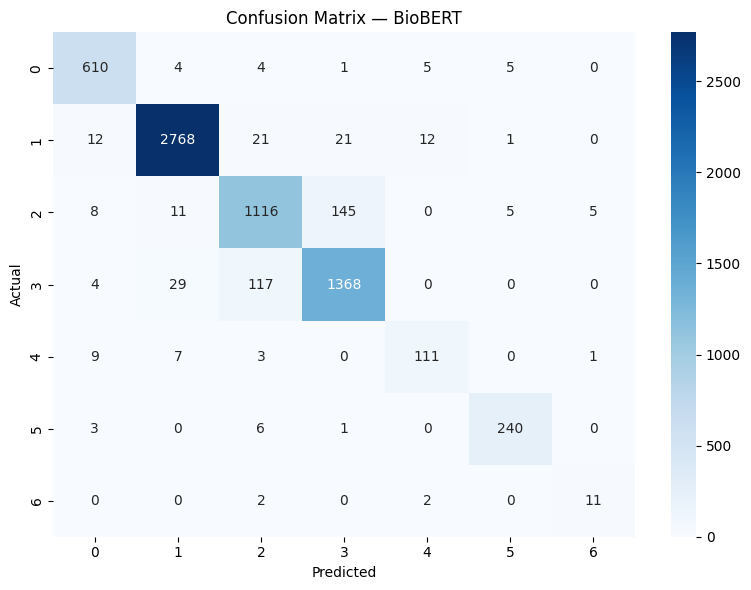

Macro AUC: 0.9942  95% CI [0.9931, 0.9952]
Saved → ./03_SameLabel/outputs/BioBERT_roc_curve.png


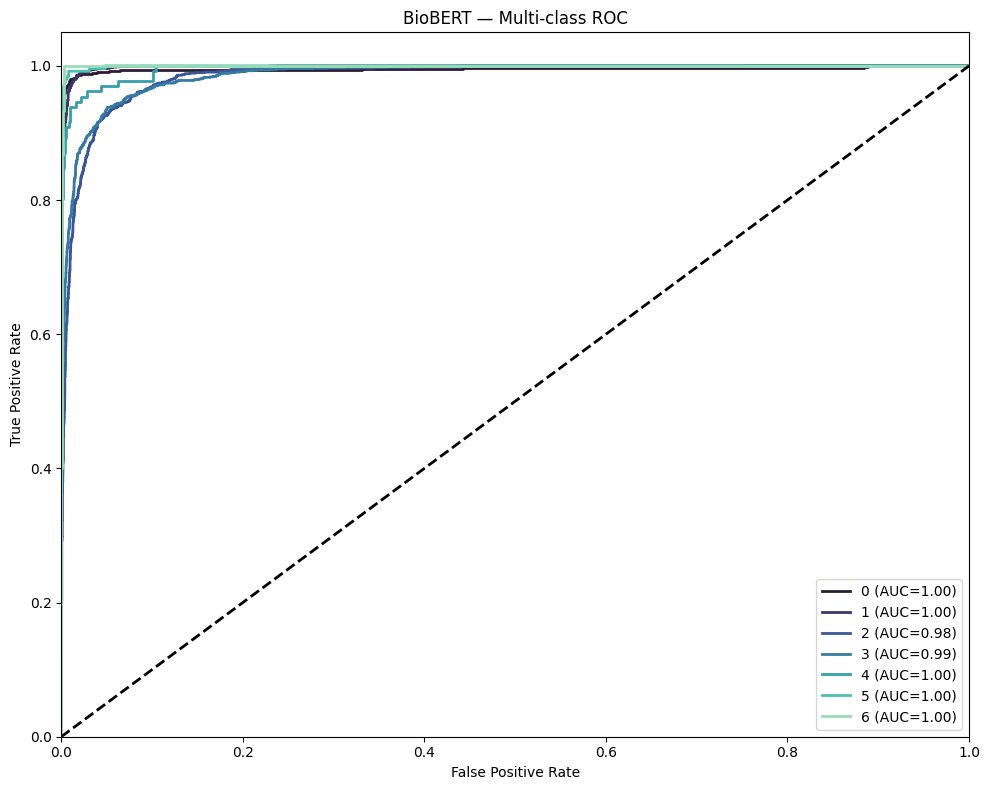

In [ ]:
biobert_preds, biobert_probs, y_true_biobert = evaluate_pytorch(
    best_biobert, test_loader_biobert, label_encoder, "BioBERT", use_attention_mask=True
)

## 4.3 Save Predictions for DL models

In [ ]:
print("\nSaving DL predictions...")

# Verify all DL models evaluated on same test set
assert np.array_equal(y_true_gru, y_true_cnn)
assert np.array_equal(y_true_gru, y_true_albert)
assert np.array_equal(y_true_gru, y_true_biobert)
y_true_dl = y_true_gru

true_names = label_encoder.inverse_transform(y_true_dl)

if "id" in df_test_dl.columns:
    df_pred_dl = df_test_dl[["id", TEXT_COLUMN, LABEL_COLUMN_ENCODED]].copy()
else:
    df_pred_dl = df_test_dl[[TEXT_COLUMN, LABEL_COLUMN_ENCODED]].copy()
    df_pred_dl.insert(0, "id", df_test_dl.index)

df_pred_dl = df_pred_dl.rename(columns={TEXT_COLUMN: "text", LABEL_COLUMN_ENCODED: "true_label_id"})
df_pred_dl["true_label"] = true_names

for name, preds, probs in [
    ("gru", gru_preds, gru_probs),
    ("cnn", cnn_preds, cnn_probs),
    ("albert", albert_preds, albert_probs),
    ("biobert", biobert_preds, biobert_probs),
]:
    df_pred_dl[f"{name}_pred_id"] = preds
    df_pred_dl[f"{name}_pred"] = label_encoder.inverse_transform(preds)
    for i, cls in enumerate(label_encoder.classes_):
        df_pred_dl[f"{name}_prob_{cls}"] = probs[:, i]

dl_pred_path = OUTPUT_PATH / "dl_models_predictions.csv"
df_pred_dl.to_csv(dl_pred_path, index=False)
print(f"Saved DL predictions → {dl_pred_path}")


Saving DL predictions...
Saved DL predictions → ./03_SameLabel/outputs/dl_models_predictions.csv


# 5. Model Comparison

In [15]:
print("\n" + "="*60)
print("MODEL COMPARISON — McNemar Pairwise Tests")
print("="*60)

# Load both prediction files
df_ml_pred = pd.read_csv(OUTPUT_PATH / "ml_models_predictions.csv")
df_dl_pred = pd.read_csv(OUTPUT_PATH / "dl_models_predictions.csv")

df_merged = pd.merge(df_ml_pred, df_dl_pred, on=["id", "true_label", "true_label_id"],
                     suffixes=("_ml", "_dl"))
print(f"Merged: {df_merged.shape[0]} rows")

y_true_all = df_merged["true_label_id"].values

# Build prediction dict
model_preds_all = {
    "LR":      label_encoder.transform(df_merged["lr_pred"].values),
    "SVM":     label_encoder.transform(df_merged["svm_pred"].values),  # <-- add this
    "RF":      label_encoder.transform(df_merged["rf_pred"].values),
    "LGBM":    label_encoder.transform(df_merged["lgbm_pred"].values),
    "GRU":     df_merged["gru_pred_id"].values,
    "CNN":     df_merged["cnn_pred_id"].values,
    "ALBERT":  df_merged["albert_pred_id"].values,
    "BioBERT": df_merged["biobert_pred_id"].values,
}

# Verify lengths
for name, arr in model_preds_all.items():
    assert len(arr) == len(y_true_all), f"{name} length mismatch"


def mcnemar_pairwise(y_true, model_preds, method="bonferroni"):
    y_true = np.asarray(y_true)
    names = list(model_preds.keys())
    results = []

    for m1, m2 in combinations(names, 2):
        y1, y2 = np.asarray(model_preds[m1]), np.asarray(model_preds[m2])
        c1 = (y1 == y_true)
        c2 = (y2 == y_true)

        a = np.sum(c1 & c2)
        b = np.sum(c1 & ~c2)
        c = np.sum(~c1 & c2)
        d = np.sum(~c1 & ~c2)

        res = mcnemar(np.array([[a, b], [c, d]]), exact=False, correction=True)
        p = res.pvalue

        if p >= 0.05:
            winner = "Inconclusive"
        elif b > c:
            winner = f"{m1} > {m2}"
        elif c > b:
            winner = f"{m2} > {m1}"
        else:
            winner = "Tie"

        results.append({
            "Model_1": m1, "Model_2": m2,
            "both_correct": a, "m1_only": b, "m2_only": c, "both_wrong": d,
            "statistic": res.statistic, "p_raw": p, "winner_raw": winner,
        })

    raw_p = [r["p_raw"] for r in results]
    _, corrected_p, _, _ = multipletests(raw_p, method=method)

    for i, pc in enumerate(corrected_p):
        results[i]["p_corrected"] = pc
        results[i]["significant"] = "Yes" if pc < 0.05 else "No"

    df_res = pd.DataFrame(results)
    print(f"\nPairwise McNemar Tests (corrected: {method}):")
    print(df_res.to_string(index=False))
    return df_res


df_mcnemar = mcnemar_pairwise(y_true_all, model_preds_all)

# Save
mcnemar_path = OUTPUT_PATH / "mcnemar_results.csv"
df_mcnemar.to_csv(mcnemar_path, index=False)
print(f"\nSaved McNemar results → {mcnemar_path}")

print("\n✓ Pipeline complete.")


MODEL COMPARISON — McNemar Pairwise Tests
Merged: 6668 rows

Pairwise McNemar Tests (corrected: bonferroni):
Model_1 Model_2  both_correct  m1_only  m2_only  both_wrong  statistic        p_raw     winner_raw  p_corrected significant
     LR     SVM          5930      123      123         492   0.004065 9.491632e-01   Inconclusive 1.000000e+00          No
     LR      RF          5586      467      245         370  68.596910 1.207932e-16        LR > RF 3.382210e-15         Yes
     LR    LGBM          5838      215      272         343   6.439425 1.116148e-02      LGBM > LR 3.125213e-01          No
     LR     GRU          5561      492      316         299  37.902228 7.438026e-10       LR > GRU 2.082647e-08         Yes
     LR     CNN          5749      304      307         308   0.006547 9.355125e-01   Inconclusive 1.000000e+00          No
     LR  ALBERT          5842      211      411         204  63.667203 1.473169e-15    ALBERT > LR 4.124874e-14         Yes
     LR BioBERT       